---
title: "Graph-Regularized Low-Rank Models (Part 1: JGB Curve)"
date: "2026-02-14"
tags: [Rates, PCA, Graphs, Japan]
categories: [Rates, Quantitative Finance, Dimensionality Reduction, Regularization]
---

Regression and PCA in finance typically ignore two sources of structure that practitioners know exist: the relationships *between* variables and the dependence along the *time index*. A cross-sectional regression of returns on characteristics treats each predictor as exchangeable; PCA of a yield panel treats each tenor as an unordered column. In reality, variables cluster into hierarchies---sector, asset class, maturity bucket---and observations are temporally ordered. I have used graph-based priors in both regression and PCA settings to encode this exogenous information, for example using hierarchical graphs to group related variables together so that coefficient or loading estimates borrow strength within economically meaningful clusters.

Econometric models take the opposite approach: VARs, state-space models, and panel regressions handle time-series and cross-sectional dependence natively, but they impose parametric structure on the dynamics---linearity, fixed lag order, homogeneous coefficients---that can be unrealistic when the data-generating process is nonstationary or high-dimensional.

Graph-regularized dimensionality reduction sits between these two traditions. The approach preserves the nonparametric flexibility of PCA while injecting structural priors through Laplacian penalties, and it can encode *both* feature relationships and temporal continuity simultaneously. I came across a paper on [Graph-Regularized Generalized Low-Rank Models (Paradkar, Udell. (2017))](https://openaccess.thecvf.com/content_cvpr_2017_workshops/w29/papers/Paradkar_Graph-Regularized_Generalized_Low-Rank_CVPR_2017_paper.pdf) that formalises this idea within a unified GLRM framework---supporting arbitrary loss functions, missing data, and two-sided graph penalties. The generality of the framework is what attracted me: the same objective can express PCA with temporal smoothing, PCA with hierarchical feature grouping, or both at once, and it extends naturally to non-Gaussian losses.

I built the [`grpca`](https://github.com/steveya/grpca) package to implement this framework with two normalisation techniques---spectral Laplacian scaling and spectral data scaling---that Paradkar and Udell did not use. These normalizations make the regularization hyperparameters dimensionless and portable across rolling windows with different sample sizes, variance levels, and graph topologies, which is essential for the kind of rolling out-of-sample evaluation used in this series.

The present post is the first in a planned series. I chose the JGB yield curve as the starting point because it is one of the first applications of PCA that people in finance learn about---a low-dimensional, well-understood setting where readers can build intuition before the framework is applied to harder problems. The yield curve is deliberately too easy for feature-side regularization: with only 11 tenors, PCA loadings are already smooth, and the interesting question is whether *temporal* regularization of the score matrix provides out-of-sample gains. Later posts will move to higher-dimensional settings where feature-side graph priors should matter more, with the eventual goal of incorporating graph-regularized PCA into nowcasting frameworks such as FAVAR, where the factor extraction step is standard PCA and replacing it with GR-PCA could improve both the factors and the downstream forecasts.

Principal component analysis is the minimum-variance linear projector and coincides with the maximum-likelihood estimator under isotropic Gaussian noise, yet it makes no use of the ordered tenor geometry or temporal continuity of yield-curve data. Graph-regularized PCA adds Laplacian roughness penalties---on the maturity axis, the time axis, or both---to the PCA objective and introduces a structure-aware bias-variance trade-off. This note evaluates PCA and GR-PCA on Japanese Ministry of Finance constant-maturity JGB yields with short rolling train-test windows and frozen out-of-sample reconstruction. The central question is which graph channel---tenor smoothness, temporal smoothness, or both---provides the most benefit, and whether any effect is concentrated in higher components.

## Theoretical underpinning

Let $X\in\mathbb{R}^{n\times p}$ denote the data matrix, with rows indexed by observations and columns indexed by features. Missing entries are allowed and are encoded as `np.nan`. We write $\Omega\subset\{1,\dots,n\}\times\{1,\dots,p\}$ for the observed-entry set and use $P_\Omega(\cdot)$ for the projection that keeps observed entries and sets missing entries to zero. After standardization, the working matrix is $Z$.

Given this notation, the estimator minimizes a masked two-sided graph-regularized low-rank objective:

$$
\min_{U\in\mathbb{R}^{n\times k},\,V\in\mathbb{R}^{p\times k}}\;
\tfrac{1}{2\,s_X}\left\|P_\Omega\!\left(Z-UV^\top\right)\right\|_F^2
\; +\; \tfrac12\lambda_s\,\operatorname{tr}(U^\top \widetilde{L}_s\, U)
\; +\; \tfrac12\lambda_f\,\operatorname{tr}(V^\top \widetilde{L}_f\, V)
\; +\; \tfrac12\mu_u\|U\|_F^2
\; +\; \tfrac12\mu_v\|V\|_F^2.
$$

The factor $U$ contains observation embeddings, $V$ contains feature loadings, $\widetilde{L}_s$ is the observation-side graph Laplacian, and $\widetilde{L}_f$ is the feature-side graph Laplacian. The ridge terms with $\mu_u,\mu_v>0$ improve coercivity and numerical conditioning.

Each graph entering the objective is assumed to be undirected and possibly weighted, with a symmetric positive-semidefinite Laplacian $L = D - W$ where $W$ is the weighted adjacency matrix and $D$ is the degree matrix. No specific topology is assumed: the framework accommodates chains, trees, complete graphs, $k$-nearest-neighbour graphs, or any other undirected weighted graph. The only mathematical requirements are symmetry ($W = W^\top$), positive semidefiniteness ($L \succeq 0$, guaranteed by construction for any combinatorial Laplacian), and separability (the observation graph $L_s \in \mathbb{R}^{n \times n}$ and the feature graph $L_f \in \mathbb{R}^{p \times p}$ are specified independently). The Laplacian quadratic form $\operatorname{tr}(U^\top L_s\, U)$ penalises disagreement between connected observations in the latent space, and $\operatorname{tr}(V^\top L_f\, V)$ penalises disagreement between connected features. The strength of the penalty between any pair $(i,j)$ is proportional to the edge weight $w_{ij}$; pairs with no edge contribute nothing.

Paradkar & Udell (2017) use raw combinatorial Laplacians $L = D - W$ and unscaled data terms. When the same model is applied across multiple data windows of different sizes, this creates a practical problem: the magnitude of the graph penalty grows with $\lambda_{\max}(L)$, which depends on graph size and edge weights, while the magnitude of the data-fidelity term scales with the variance and dimension of the data matrix. A fixed $\lambda$ that provides moderate regularization in one setting can be negligible or overwhelming in another. Our implementation introduces two normalizations that make the hyperparameters dimensionless and portable. First, every graph Laplacian entering the objective is divided by its largest eigenvalue: $\widetilde{L} = L / \lambda_{\max}(L)$, so that $\lambda_{\max}(\widetilde{L}) = 1$. (The spectral normalization is distinct from the symmetric normalized Laplacian $D^{-1/2}LD^{-1/2}$; our normalization applies to whatever Laplacian the user supplies, including already degree-normalized ones.) With this convention, the quadratic form $\operatorname{tr}(V^\top \widetilde{L} V)$ lies in $[0, \|V\|_F^2]$ for any graph, so the regularization strength has a graph-independent upper bound on its effect. Second, the reconstruction term is divided by $s_X = \sigma_1^2(Z_{\text{fill}})$, the squared leading singular value of the zero-filled standardized data matrix, scaling the data-fidelity term to order one regardless of sample size or variance level. Together, these normalizations mean that a given $\tau$ value represents roughly the same bias-variance trade-off regardless of sample size, data variance, or graph topology. The combined normalization allows a single hyperparameter grid to be used across multiple estimation windows without per-window rescaling.

The factorization $UV^\top$ is not unique: for any orthogonal $R\in\mathbb{R}^{k\times k}$, the rotated pair $(UR,VR)$ produces the same product. Individual columns of $V$ are therefore not uniquely identified as fixed population eigenvectors, and raw column-wise comparisons across estimation windows can be misleading. Meaningful comparison operates at the subspace level or after Procrustes alignment. Ridge penalties on both $U$ and $V$ improve numerical conditioning but do not resolve this rotational ambiguity. To simplify the hyperparameter search space, we parameterize regularization by total strength $\tau\ge 0$ and allocation $\rho\in[0,1]$:

$$
\lambda_s=\tau\rho,\qquad \lambda_f=\tau(1-\rho).
$$

The reparametrization separates overall shrinkage intensity from how shrinkage is split between observation-side smoothness ($U$) and feature-side smoothness ($V$). Since both Laplacians and data are normalized, $\tau$ is dimensionless, comparable across windows, and more interpretable than tuning raw penalty magnitudes independently.

Paradkar & Udell (2017) solve Graph-Regularized GLRMs with **PALM** (Proximal Alternating Linearized Minimization), a framework designed for general (possibly non-smooth) loss functions such as Huber, hinge, or ordinal losses. Each PALM iteration linearizes the smooth data-fidelity term around the current iterate and applies a loss-specific proximal operator, with convergence guaranteed under a Lipschitz step-size rule. Restricting to **squared-error loss** makes the objective everywhere differentiable in $(U,V)$, and the proximal operator reduces to the identity. The full PALM machinery is therefore unnecessary. Our implementation (`grpca`) replaces it with **alternating gradient descent with monotone backtracking line search**: each outer iteration computes the closed-form gradient

$$\nabla_U = \frac{1}{s_X}\,P_\Omega\!\bigl(UV^\top\!-Z\bigr)\,V + \lambda_s\,\widetilde{L}_s\,U + \mu_u\,U, \qquad \nabla_V = \frac{1}{s_X}\,P_\Omega\!\bigl(UV^\top\!-Z\bigr)^\top U + \lambda_f\,\widetilde{L}_f\,V + \mu_v\,V,$$

takes a gradient step $U \leftarrow U - \eta\,\nabla_U$ (then $V \leftarrow V - \eta\,\nabla_V$), and halves the step size $\eta$ until the objective decreases monotonically. Convergence to a stationary point follows from the standard descent-lemma argument for smooth bi-convex problems. Unlike Paradkar & Udell's general framework, which optionally includes $\ell_1$ sparsity on $U$ or $V$, we use dense (unpenalized) factors throughout---appropriate for settings where all features contribute to each latent factor. We initialize factors with a truncated SVD of the zero-filled matrix, providing a good starting point that typically converges in tens of iterations.

The two penalty terms have natural economic readings in the yield-curve context. The observation-side penalty on $U$ encodes the prior that factor exposures---the market's aggregate assessment of the policy rate (level), the term premium (slope), and convexity demand (curvature)---evolve smoothly from one trading day to the next. This is the same "slow-moving factor" assumption that underlies Kalman-filtered dynamic factor models (Stock and Watson, Doz et al.), where the state-transition equation $u_t = u_{t-1} + \eta_t$ imposes temporal continuity; the day-chain penalty strength $\tau\rho$ plays an analogous role to the signal-to-noise ratio in that framework. The feature-side penalty on $V$ encodes the prior that adjacent maturities load similarly on each factor---a discrete, nonparametric analogue of the smooth loading functions $B(\tau)$ in affine term-structure models, where the Ricatti ODEs guarantee that loadings vary continuously with maturity. Nelson-Siegel achieves this smoothness parametrically through exponential-decay basis functions; the tenor-chain Laplacian achieves it nonparametrically. Finally, the masked reconstruction loss has a direct financial application: it asks "given 10 of 11 tenors, how well can the model predict the held-out tenor?"---precisely the question a relative-value trader poses when identifying rich or cheap points on the curve, or a risk manager faces when interpolating illiquid tenor points from liquid ones.

## JGB experiment setup

The data are Japanese Ministry of Finance constant-maturity JGB yields. We work with a stable subset of tenors (in years) and compute daily yield changes. We standardize each rolling window using train-window statistics only; the train mean and standard deviation are applied to the test window with no leakage.

We instantiate the framework with two chain graphs that encode the known structure of yield-curve data. The **tenor-chain** (feature graph) connects adjacent maturities with edge weights inversely proportional to the squared maturity gap:

$$
w_{i,i+1}^{(f)} = \frac{1}{(\Delta m_{i})^2}, \qquad \Delta m_i = m_{i+1} - m_i,
$$

where $m_i$ is the maturity in years of the $i$-th tenor. The weighting gives tighter coupling between closely spaced tenors (e.g., 1Y--2Y) and weaker coupling between widely spaced ones (e.g., 20Y--30Y). The Laplacian quadratic form admits the pairwise-difference identity

$$
\operatorname{tr}(V^\top \widetilde{L}_f\, V) = \tfrac{1}{2}\sum_{i} \tilde{w}_{i,i+1}^{(f)}\,\|v_i - v_{i+1}\|_2^2,
$$

which penalizes high-frequency oscillation in the loading vectors: neighboring tenors are encouraged to have similar loading coordinates. The **day-chain** (observation graph) connects consecutive trading dates with unit weight. The day-chain is rebuilt on each training window so that its dimension matches the number of training observations. The analogous quadratic form

$$
\operatorname{tr}(U^\top \widetilde{L}_s\, U) = \tfrac{1}{2}\sum_{t} \tilde{w}_{t,t+1}^{(s)}\,\|u_t - u_{t+1}\|_2^2
$$

penalizes abrupt jumps in the latent score trajectories between adjacent dates, encoding temporal continuity of the factor structure.

We compare four specifications, all with $k = 3$ latent components:

| Model | Observation graph | Feature graph | CV search |
|-------|-------------------|---------------|-----------|
| **PCA** | --- | --- | $\tau = 0$ (no CV) |
| **Day** | day-chain | --- | $\tau$ with $\rho = 1$ |
| **Tenor** | --- | tenor-chain | $\tau$ with $\rho = 0$ |
| **Day+Tenor** | day-chain | tenor-chain | $\tau$ and $\rho \in \{0.25, 0.5, 0.75\}$ |

Nested time-series cross-validation selects $(\tau, \rho)$ window by window. Before stating the empirical objective, the data and graph structure that these penalties will act on are examined below.

In [1]:
#| echo: false
#| output: false
#| warning: false
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

# Blog-local modules (blog_styles lives at site root)
_site_root = Path.cwd().parent.parent          # steveya.github.io
if _site_root.exists() and str(_site_root) not in sys.path:
    sys.path.insert(0, str(_site_root))

# Blog styling
from blog_styles import (
    apply_blog_plot_style, inject_blog_table_css,
    style_results_table, BLOG_PALETTE,
    plot_labeled_heatmap,
)

inject_blog_table_css()
apply_blog_plot_style()

# GR-PCA estimator and utilities  (pip install git+https://github.com/steveya/grpca.git)
from grpca import GraphRegularizedPCA, RollingWindowSplitter
from grpca.graphs import tenor_chain_graph, day_chain_graph
from grpca.metrics import (
    procrustes_distance, subspace_distance,
    feature_roughness, example_roughness,
)
from grpca.diagnostics import dm_test

# MOF data source  (pip install git+https://github.com/steveya/alphaforge.git)
from alphaforge.data.public_web.mof_jgb import MOFJGBYieldCurveSource

DATA_DIR = Path('data')
DATA_DIR.mkdir(parents=True, exist_ok=True)

tau_grid = np.array([0.0, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 0.1], dtype=float)
rho_grid = np.array([0.0, 0.25, 0.5, 0.75, 1.0], dtype=float)
train_years = 1
test_months = 3
step_months = 1
min_train_obs = 180
min_test_obs = 40

In [2]:
#| echo: false
#| output: false

# Load via alphaforge DataSource
mof_source = MOFJGBYieldCurveSource(cache_dir=DATA_DIR)
jgb_yields_raw = mof_source.fetch_wide()

# fetch_wide returns UTC-aware date index; normalise to date-only
if hasattr(jgb_yields_raw.index, 'tz') and jgb_yields_raw.index.tz is not None:
    jgb_yields_raw.index = jgb_yields_raw.index.tz_localize(None)
jgb_yields_raw.index.name = 'Date'

# Balanced-panel start: first date where all 11 main tenors have data.
# Exclude 40Y (not issued until 2007) so the main analysis starts from ~1999.
_main_tenors = ['1Y','2Y','3Y','5Y','7Y','8Y','9Y','10Y','15Y','20Y','30Y']
_main_cols = [c for c in _main_tenors if c in jgb_yields_raw.columns]
all_tenors_start = jgb_yields_raw[_main_cols].dropna(how='any').index.min()
if pd.isna(all_tenors_start):
    all_tenors_start = jgb_yields_raw.index.min()

,pre_1999_mean,pre_1999_vol_ann,1999_2007_mean,1999_2007_vol_ann,post_2007_mean,post_2007_vol_ann
tenor,,,,,,
1Y,-0.0024,0.6605,0.0003,0.1343,0.0001,0.1403
2Y,-0.0018,0.6069,0.0002,0.2120,0.0001,0.1866
3Y,-0.0013,0.6059,0.0002,0.3019,0.0001,0.2201
5Y,-0.0011,0.6281,-0.0000,0.4164,0.0001,0.2930
7Y,-0.0010,0.7101,-0.0001,0.5068,0.0001,0.3743
8Y,-0.0010,0.7239,-0.0002,0.4949,0.0001,0.3656
9Y,-0.0010,0.6855,-0.0001,0.4753,0.0001,0.3465
10Y,-0.0010,0.7945,-0.0001,0.4685,0.0001,0.3264
15Y,-0.0021,0.6267,-0.0002,0.4813,0.0002,0.3479


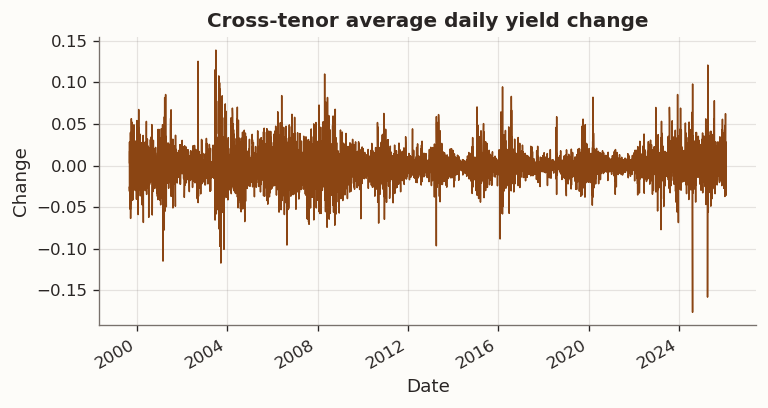

In [20]:
#| echo: false
#| label: fig-yield-changes
#| fig-cap: "Cross-tenor average daily yield change over the sample period"
_parse_maturity = MOFJGBYieldCurveSource._parse_maturity_years

preferred_tenors = ['1Y','2Y','3Y','5Y','7Y','8Y','9Y','10Y','15Y','20Y','30Y']
available = [c for c in preferred_tenors if c in jgb_yields_raw.columns]
if len(available) < 8:
    available = [c for c in jgb_yields_raw.columns if (isinstance(_parse_maturity(c), float) and _parse_maturity(c) >= 1.0)]

jgb_yields = jgb_yields_raw[available].copy().sort_index().dropna(how='all')

# Restrict to dates where ALL tenors have real data (no backward imputation).
# The 30Y JGB first appears in 1999; using interpolate(limit_direction='both')
jgb_yields = jgb_yields.loc[all_tenors_start:]

# Forward-fill sporadic gaps (limit=5 business days) then drop remaining NaN rows
jgb_yields = jgb_yields.interpolate(limit=5, limit_direction='forward').dropna()
jgb_changes = jgb_yields.diff().dropna()
tenor_labels = list(jgb_changes.columns)
maturities_years = np.array([_parse_maturity(c) for c in tenor_labels], dtype=float)
order = np.argsort(maturities_years)
maturities_years = maturities_years[order]
tenor_labels = [tenor_labels[i] for i in order]
jgb_changes = jgb_changes[tenor_labels]

# Descriptive stats table (include 40Y) over three calendar periods
stats_tenors = preferred_tenors + ['40Y']
available_stats = [c for c in stats_tenors if c in jgb_yields_raw.columns]
jgb_yields_stats = jgb_yields_raw[available_stats].copy().sort_index().dropna(how='all')
jgb_yields_stats = jgb_yields_stats.interpolate(limit=5, limit_direction='forward')
jgb_changes_stats = jgb_yields_stats.diff()

stats_labels = list(jgb_changes_stats.columns)
stats_maturities = np.array([_parse_maturity(c) for c in stats_labels], dtype=float)
order_stats = np.argsort(stats_maturities)
stats_labels = [stats_labels[i] for i in order_stats]
jgb_changes_stats = jgb_changes_stats[stats_labels]

cut_1999 = pd.Timestamp('1999-09-03')
cut_2007 = pd.Timestamp('2007-11-07')

period_masks = {
    'pre_1999': jgb_changes_stats.index < cut_1999,
    '1999_2007': (jgb_changes_stats.index >= cut_1999) & (jgb_changes_stats.index < cut_2007),
    'post_2007': jgb_changes_stats.index >= cut_2007,
}

tenor_stats = pd.DataFrame(index=jgb_changes_stats.columns)
for period, mask in period_masks.items():
    period_slice = jgb_changes_stats.loc[mask]
    tenor_stats[f'{period}_mean'] = period_slice.mean(axis=0)
    tenor_stats[f'{period}_vol_ann'] = period_slice.std(axis=0, ddof=1) * np.sqrt(252)

tenor_stats.index.name = 'tenor'
tenor_stats = tenor_stats.reset_index()
display(style_results_table(tenor_stats, precision=4, index_col='tenor'))

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(jgb_changes.index, jgb_changes.mean(axis=1), lw=0.9)
ax.set_title('Cross-tenor average daily yield change')
ax.set_ylabel('Change')
ax.set_xlabel('Date')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

@fig-yield-changes reveals several distinct volatility regimes driven by Bank of Japan policy shifts. The 2013 Quantitative and Qualitative Easing (QQE) announcement---Kuroda's "shock-and-awe" bond-buying programme---triggered a 10Y limit-down and an abrupt widening of daily yield moves across the curve. Three years later the introduction of Yield Curve Control (YCC) in September 2016 explicitly capped the 10Y yield at approximately 0%, compressing daily volatility to near-zero for several years. The unwinding of that regime from December 2022 (YCC band widened to ±50 bp) through March 2024 (exit from YCC) produced a volatility resurgence, particularly at intermediate tenors.

Two features are relevant for the graph-regularization setup. First, the regime heterogeneity motivates per-window standardisation (train-window mean and variance applied without leakage) and short one-year rolling windows that adapt to local market conditions. Second, the visible low-frequency structure in daily yield changes---slow regime evolution punctuated by policy-driven jumps---suggests the day-chain temporal-smoothness prior should be well-calibrated: true factor scores evolve on weekly-to-monthly time scales, so penalising day-to-day score jumps is unlikely to remove genuine signal. The day-chain itself is simply a unit-weighted path graph on $n$ consecutive training dates and needs no separate visualisation; its only role is to encode the ordering of observations.

@fig-graph-priors displays the tenor-chain adjacency matrix $W$ that enters the feature-side Laplacian $L_f = D - W$. The inverse-squared-gap weighting produces a tight cluster at 7Y--8Y--9Y (gap = 1 year, weight $= 1.0$) and much weaker coupling between distant tenors such as 20Y--30Y (gap = 10 years, weight $= 0.01$). The penalty therefore concentrates its effect on tenors that already co-move almost perfectly---precisely the region where PCA loadings are smoothest and least in need of regularisation.

There is also a structural mismatch with the JGB policy environment. Under YCC the BOJ intervened specifically at the 10Y tenor, decoupling it from its nearest neighbours and creating a kink in the yield curve that traditional chain-graph smoothing would treat as noise. The wider maturity gaps where such policy-induced discontinuities appear receive the least penalty weight ($0.04$ for 10Y--15Y, $0.01$ for 20Y--30Y). Whether this graph topology provides any variance reduction, or merely adds bias by smoothing through genuine structural breaks, is assessed empirically below.

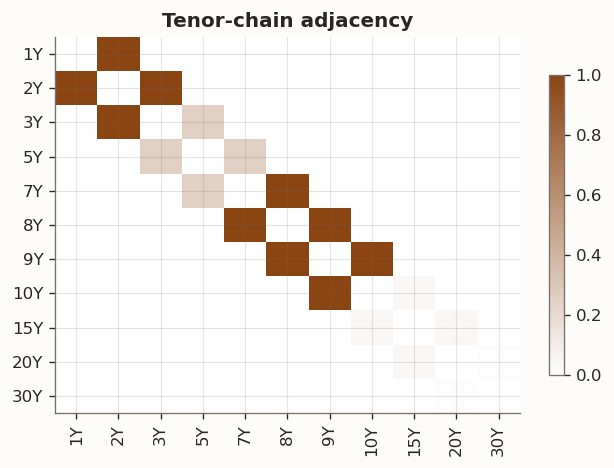

In [4]:
#| echo: false
#| label: fig-graph-priors
#| fig-cap: "Adjacency matrix for the tenor-chain feature graph"
from matplotlib.colors import LinearSegmentedColormap

W_tenor, L_tenor, Ltilde_tenor = tenor_chain_graph(maturities_years)

_blog_cmap = LinearSegmentedColormap.from_list('blog_brown', ['#FFFFFF', BLOG_PALETTE[0]])

fig, ax = plt.subplots(figsize=(5.5, 4))
plot_labeled_heatmap(W_tenor, tenor_labels, title='Tenor-chain adjacency', ax=ax,
                     cmap=_blog_cmap)
plt.tight_layout()
plt.show()

## Empirical objective

The empirical study in this note is not meant to validate graph regularization in the abstract. The goal is narrower: to assess, on JGB curve changes, what changes when graph-structured shrinkage is added to a masked low-rank model, and to identify which regularization terms are active under time-series cross-validation. The model differs from an unregularized low-rank fit only through two quadratic penalties. The day-chain term $\operatorname{tr}(U^\top L_s U)$ penalizes temporal roughness of the score trajectories, while the tenor-chain term $\operatorname{tr}(V^\top L_f V)$ penalizes roughness of loadings across maturities. This structure suggests a natural evaluation order. The first step is to verify whether the corresponding roughness functional declines relative to the unregularized fit. The second step is to evaluate whether any induced smoothness improves masked out-of-sample reconstruction on held-out blocks. The final step is to examine how the estimated factor geometry evolves across windows under stability metrics that remain meaningful for GLRM.

Two competing mechanisms frame interpretation without presuming improvement. Variance-directed shrinkage is relevant when short rolling windows and weak identification allow a low-rank fit to allocate degrees of freedom to high-frequency patterns. Under this mechanism, day-side shrinkage should primarily appear as a reduction in score roughness $\operatorname{tr}(U^\top L_s U)$, while tenor-side shrinkage should primarily appear as a reduction in loading roughness $\operatorname{tr}(V^\top L_f V)$. Bias dominance becomes relevant when the baseline solution is already smooth relative to the imposed graph geometry. Under that mechanism, additional shrinkage has little variance to remove and mainly distorts the optimum; cross-validation should then select $\tau=0$, and the regularized model should collapse back to the unregularized fit. The empirical study is designed to distinguish between these mechanisms for each graph in the JGB setting.

The objective is evaluated with diagnostics directly tied to the objective terms and valid under GLRM identifiability. Roughness is tracked through $\operatorname{tr}(U^\top L_s U)$ and $\operatorname{tr}(V^\top L_f V)$. Window-to-window changes in factor geometry are summarized by two complementary stability metrics: subspace distance $\sin\theta_{\max}$, defined as the sine of the largest principal angle between consecutive loading subspaces computed after orthonormalization, and Procrustes drift $\min_R\|V_t - V_{t-1}R\|_F$, defined as the Frobenius residual after optimal orthogonal alignment in latent space. Masked out-of-sample reconstruction error on held-out test blocks anchors the comparison, so any gain in smoothness is judged against generalization cost. The study proceeds from full-sample fits to rolling evaluation at multiple window lengths, allowing the same objective to be assessed both in aggregate and under short-sample estimation stress.

## Full-sample study

Four specifications are fit on the full sample with $k=3$: an unregularized baseline (PCA), Day (day-chain only), Tenor (tenor-chain only), and Day+Tenor. Hyperparameters are selected via time-series cross-validation. The factorization $UV^\top$ is invariant under orthogonal rotation in latent space, so loading vectors are compared only after orthogonal Procrustes alignment to a common baseline. The figures therefore report aligned loading profiles rather than raw column vectors.

Cross-validation outcomes and the two roughness diagnostics provide the first indication of which regularization terms are active in this dataset. The aligned loading and score figures are interpreted through that lens. Temporal smoothing is assessed through changes in $\operatorname{tr}(U^\top L_s U)$ and through the resulting score paths, while maturity smoothing is assessed through $\operatorname{tr}(V^\top L_f V)$ and through the aligned loading geometry.

,day_graph,tenor_graph,tau,rho,lambda_s,lambda_f,recon_error,loading_roughness,score_roughness
model,,,,,,,,,
PCA,False,False,0.0000,0.0000,0.0000,0.0000,0.9874,0.0011,5908694.7152
Day,True,False,0.0100,1.0000,0.0100,0.0000,0.9728,0.0024,125820.9565
Tenor,False,True,0.0000,0.0000,0.0000,0.0000,0.9874,0.0011,5908694.7152
Day+Tenor,True,True,0.0300,0.5000,0.0150,0.0150,0.9734,0.0023,66555.2307


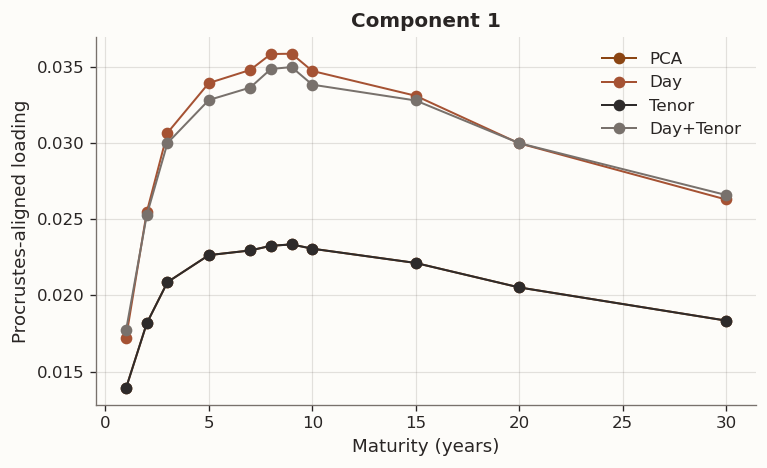

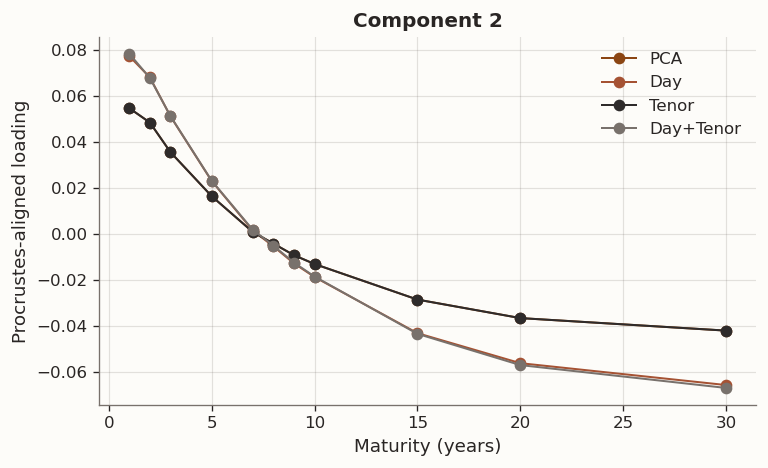

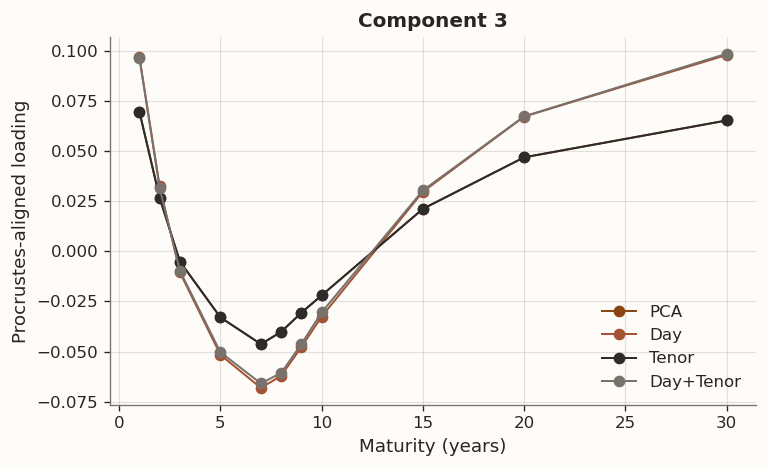

In [98]:
#| echo: false
#| warning: false
#| label: fig-full-sample-loading-comparison
#| fig-cap: "Full-sample Procrustes-aligned loading comparison (k=3) across PCA, Day, Tenor, and Day+Tenor GLRM models with cross-validated hyperparameters"

k_full = 3
X_full = jgb_changes.to_numpy(dtype=float)
dates_full = pd.DatetimeIndex(jgb_changes.index)

# Day-chain example graph on the full sample
W_day_full, L_day_full, Ltilde_day_full = day_chain_graph(dates_full, normalize=True)

# ── Model specifications ────────────────────────────────────────────────
full_sample_specs = {
    'PCA': dict(
        graph=None, example_graph=None,
        tau=0.0, rho=0.0,
    ),
    'Day': dict(
        graph=None, example_graph=Ltilde_day_full,
        cv='nested_ts', tau_grid=tau_grid, rho_grid=np.array([1.0]),
        delta=0.01,
    ),
    'Tenor': dict(
        graph=Ltilde_tenor, example_graph=None,
        cv='nested_ts', tau_grid=tau_grid, rho_grid=np.array([0.0]),
        delta=0.01,
    ),
    'Day+Tenor': dict(
        graph=Ltilde_tenor, example_graph=Ltilde_day_full,
        cv='nested_ts', tau_grid=tau_grid, rho_grid=np.array([0.25, 0.5, 0.75]),
        delta=0.01,
    ),
}

# ── Fit all models ──────────────────────────────────────────────────────
fitted_models_full = {}
for name, spec in full_sample_specs.items():
    model = GraphRegularizedPCA(
        n_components=k_full,
        standardize=True,
        **spec,
    )
    model.fit(X_full, dates=dates_full)
    fitted_models_full[name] = model

# ── Procrustes alignment to PCA baseline ────────────────────────────────
V_pca = fitted_models_full['PCA'].V_.copy()
aligned_full = {'PCA': V_pca.copy()}

for name in ['Day', 'Tenor', 'Day+Tenor']:
    V_m = fitted_models_full[name].V_.copy()
    cross = V_m.T @ V_pca
    U_svd, _, Wt_svd = np.linalg.svd(cross, full_matrices=False)
    R = U_svd @ Wt_svd
    aligned_full[name] = V_m @ R

# ── Results table ───────────────────────────────────────────────────────
table_rows = []
for name, model in fitted_models_full.items():
    has_tenor = model.has_feature_graph_
    has_day = model.has_example_graph_

    recon = float(model.reconstruction_error(X_full, k=k_full))
    f_rough = float(feature_roughness(model.V_, Ltilde_tenor))
    s_rough = float(example_roughness(model.U_, Ltilde_day_full))

    table_rows.append({
        'model': name,
        'day_graph': has_day,
        'tenor_graph': has_tenor,
        'tau': float(model.tau_),
        'rho': float(model.rho_),
        'lambda_s': float(model.lambda_s_),
        'lambda_f': float(model.lambda_f_),
        'recon_error': recon,
        'loading_roughness': f_rough,
        'score_roughness': s_rough,
    })

summary_full_df = pd.DataFrame(table_rows)
display(style_results_table(summary_full_df, precision=4, index_col='model'))

# ── Loading comparison: one figure per component ────────────────────────
model_order = ['PCA', 'Day', 'Tenor', 'Day+Tenor']
for comp in range(k_full):
    fig, ax = plt.subplots(figsize=(6.5, 4))
    for name in model_order:
        ax.plot(maturities_years, aligned_full[name][:, comp],
                marker='o', lw=1.2, label=name)
    ax.set_title(f'Component {comp + 1}')
    ax.set_xlabel('Maturity (years)')
    ax.set_ylabel('Procrustes-aligned loading')
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

In GLRM the factorisation $UV^\top$ is invariant under orthogonal rotation, so individual columns of $V$ are not uniquely identified. The loading comparison above first aligns each model to the PCA baseline via orthogonal Procrustes, which finds the rotation $R^\star=\arg\min_R\|V_{\text{PCA}}-V_{\text{model}}R\|_F$ subject to $R^\top R=I$. Differences that remain after alignment reflect genuine changes in the factor geometry, not relabelling or sign ambiguity.

The Procrustes-aligned loading profiles are consistent with the standard yield-curve factor taxonomy. Component 1 is a *level* factor: positive loadings across all tenors with a broad plateau at intermediate maturities, corresponding to parallel shifts driven by the common component of rate expectations. Component 2 is a *slope* factor: monotonically decreasing from positive at the short end to negative at the long end, capturing the steepening and flattening moves associated with BOJ accommodation cycles and term-premium variation. Component 3 is a *curvature* (butterfly) factor: a hump-shaped profile peaking around 5Y–7Y, reflecting the belly-vs.-wings dynamics that arise from supply concentration in benchmark tenors and relative-value positioning. Together the three components explain the vast majority of daily yield-change variation, consistent with decades of term-structure research on both U.S. Treasuries and JGBs.

The results table reveals an immediate finding: cross-validation selects $\tau=0$ for the Tenor model, collapsing it to PCA. The tenor-chain smoothness prior brings no improvement to the full-sample validation loss, so the conservative selection rule defaults to zero regularisation. By contrast, the Day model selects $\tau=0.01$ and the Day+Tenor model selects $\tau=0.03$ ($\rho=0.5$), and both achieve lower in-sample reconstruction error than PCA. Day-graph regularisation sharply reduces score roughness $\operatorname{tr}(U^\top L_s U)$, confirming that the temporal-smoothness penalty reaches its intended target. The rolling study below examines whether these in-sample improvements persist out of sample.

In [99]:
#| echo: false
#| warning: false
#| label: tbl-explained-variance
#| tbl-cap: "Explained variance by PCA component (full sample)"

# Compute explained-variance ratios from the SVD of the centred yield-change matrix
X_c = X_full - X_full.mean(axis=0)
_, S_full, _ = np.linalg.svd(X_c, full_matrices=False)
var_ratios = (S_full ** 2) / (S_full ** 2).sum()
cum_ratios = np.cumsum(var_ratios)

ev_df = pd.DataFrame({
    'Component': [f'{i+1}' for i in range(min(5, len(var_ratios)))],
    'Variance explained (%)': [f'{v*100:.2f}' for v in var_ratios[:5]],
    'Cumulative (%)': [f'{c*100:.2f}' for c in cum_ratios[:5]],
})
display(style_results_table(ev_df, precision=2, index_col='Component'))

,Variance explained (%),Cumulative (%)
Component,,
1,83.39,83.39
2,10.53,93.92
3,3.08,97.00
4,0.98,97.98
5,0.62,98.60


In [100]:
#| echo: false
#| output: false

# ── BOJ policy event markers (shared across all charts) ────────────────
import matplotlib.dates as mdates

BOJ_EVENTS = [
    ('2003-06-11', 'VaR shock'),
    ('2006-07-14', 'End ZIRP'),
    ('2013-04-04', 'QQE'),
    ('2016-01-29', 'NIRP'),
    ('2016-09-21', 'YCC'),
    ('2020-03-16', 'COVID'),
    ('2022-12-20', 'YCC ±50bp'),
    ('2024-03-19', 'Exit YCC'),
]

def add_boj_events(ax, events=BOJ_EVENTS, y_frac=0.97, fontsize=7):
    """Draw vertical event lines and rotated labels on *ax*."""
    xlims = ax.get_xlim()
    for date_str, label in events:
        dt = pd.Timestamp(date_str)
        xnum = mdates.date2num(dt)
        if xnum < xlims[0] or xnum > xlims[1]:
            continue
        ax.axvline(dt, color='grey', ls=':', lw=0.7, alpha=0.6, zorder=0)
        ax.text(
            dt, ax.get_ylim()[0] + y_frac * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            label, rotation=90, va='top', ha='right',
            fontsize=fontsize, color='grey', alpha=0.8,
        )

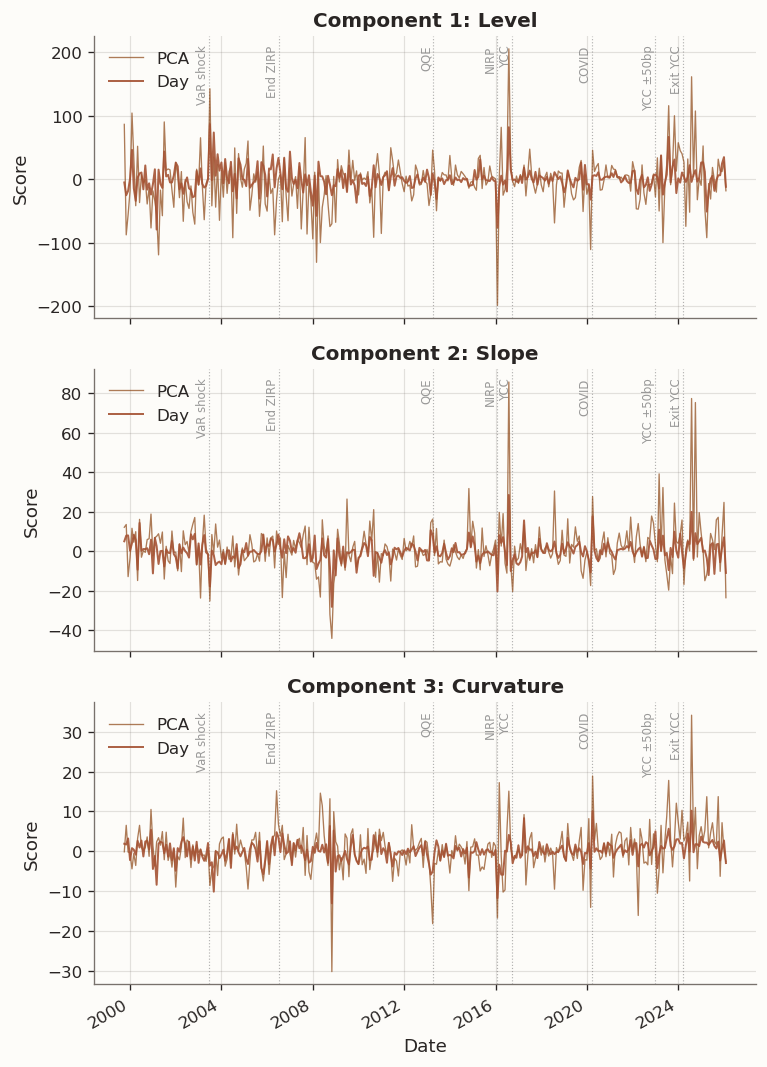

In [127]:
#| echo: false
#| warning: false
#| label: fig-score-trajectories
#| fig-cap: "Full-sample factor scores (monthly last, level/slope/curvature) for PCA vs Day-regularised model with BOJ policy events"

comp_labels = ['Level', 'Slope', 'Curvature']
fig, axes = plt.subplots(3, 1, figsize=(6.5, 9), sharex=True)

U_pca = fitted_models_full['PCA'].U_.copy()
U_day = fitted_models_full['Day'].U_.copy()

# Align Day scores to PCA sign convention (flip if correlation < 0)
for c in range(3):
    if np.corrcoef(U_pca[:, c], U_day[:, c])[0, 1] < 0:
        U_day[:, c] *= -1

# Monthly resample (last business day of month) for visual clarity
_score_pca = pd.DataFrame(U_pca, index=dates_full, columns=comp_labels)
_score_day = pd.DataFrame(U_day, index=dates_full, columns=comp_labels)
_score_pca_m = _score_pca.resample('ME').last().dropna()
_score_day_m = _score_day.resample('ME').last().dropna()

for c in range(3):
    lbl = comp_labels[c]
    axes[c].plot(_score_pca_m.index, _score_pca_m[lbl], lw=0.8, alpha=0.7, label='PCA')
    axes[c].plot(_score_day_m.index, _score_day_m[lbl], lw=1.2, alpha=0.9, label='Day')
    axes[c].set_title(f'Component {c+1}: {lbl}')
    axes[c].set_ylabel('Score')
    axes[c].legend(loc='upper left')
    axes[c].grid(alpha=0.2)
    add_boj_events(axes[c])

axes[2].set_xlabel('Date')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The score trajectories (plotted at month-end frequency for visual clarity; the smoothing effect is present in the underlying daily data) make the effect of day-chain regularisation visually concrete. The PCA level score (Component 1) displays rapid oscillations that are largely absent in the Day-regularised counterpart, which tracks a smoother path through the same macro regimes---the 2003 VaR shock sell-off, the 2008 GFC flight-to-quality, the 2013 QQE-induced volatility, and the 2022–2024 YCC exit. The smoothing is most dramatic in the curvature score (Component 3), where PCA produces chaotic high-frequency noise while the Day model isolates a slowly evolving butterfly signal.

In [5]:
#| echo: false
#| output: false
#| warning: false

import time

try:
    from tqdm import tqdm
except Exception:
    def tqdm(iterable=None, **kwargs):
        return iterable

# ── Constants ───────────────────────────────────────────────────────────
PCA_METHOD   = 'PCA'
DAY_METHOD   = 'Day'
TENOR_METHOD = 'Tenor'
BOTH_METHOD  = 'Day+Tenor'
GR_METHODS   = [DAY_METHOD, TENOR_METHOD, BOTH_METHOD]
METHODS      = [PCA_METHOD] + GR_METHODS

k_roll = 3          # rolling rank consistent with full-sample study

X = jgb_changes.to_numpy(dtype=float)
idx = pd.DatetimeIndex(jgb_changes.index)

# ── Rolling windows ─────────────────────────────────────────────────────
splitter = RollingWindowSplitter(
    train_len='365D', test_len='92D', step='30D',
    min_train_obs=min_train_obs, min_test_obs=min_test_obs,
)
windows = list(splitter.split_with_info(X, groups=idx))

# ── Storage ─────────────────────────────────────────────────────────────
prev_loadings   = {m: None for m in METHODS}
eval_rows       = []
reg_rows        = []
roughness_rows  = []
stability_rows  = []
timing_rows     = []
loadings_store  = {}

total_fits = len(windows) * len(METHODS)
fit_pbar = tqdm(total=total_fits, desc='Rolling GLRM fits', leave=False)
window_iter = tqdm(enumerate(windows), total=len(windows), desc='Windows', leave=False)

for w_id, (end_dt, tr_idx, te_idx) in window_iter:
    window_t0 = time.perf_counter()
    X_train, X_test = X[tr_idx], X[te_idx]
    train_dates = idx[tr_idx]

    # Window-specific day-chain example graph (train dates only).
    _, _, Ltilde_day_w = day_chain_graph(train_dates, normalize=True)

    for method in METHODS:
        fit_t0 = time.perf_counter()

        # ── Model spec (CV per model, matching full-sample study) ───
        if method == PCA_METHOD:
            spec = dict(graph=None, example_graph=None, tau=0.0, rho=0.0)
        elif method == DAY_METHOD:
            spec = dict(
                graph=None, example_graph=Ltilde_day_w,
                cv='nested_ts', tau_grid=tau_grid, rho_grid=np.array([1.0]),
                delta=0.01,
            )
        elif method == TENOR_METHOD:
            spec = dict(
                graph=Ltilde_tenor, example_graph=None,
                cv='nested_ts', tau_grid=tau_grid, rho_grid=np.array([0.0]),
                delta=0.01,
            )
        else:  # BOTH
            spec = dict(
                graph=Ltilde_tenor, example_graph=Ltilde_day_w,
                cv='nested_ts', tau_grid=tau_grid, rho_grid=np.array([0.25, 0.5, 0.75]),
                delta=0.01,
            )

        model = GraphRegularizedPCA(
            n_components=k_roll,
            standardize=True,
            **spec,
        )
        model.fit(X_train, dates=train_dates, P_prev=prev_loadings[method])
        V_curr = model.V_.copy()

        # OOS masked reconstruction loss at k=3.
        eval_rows.append({
            'window_id': w_id, 'window_end': end_dt, 'method': method,
            'loss_oos': float(model.reconstruction_error(X_test, k=k_roll, per_obs=False)),
        })

        # Selected hyperparameters.
        cv_res = model.cv_results_
        reg_rows.append({
            'window_id': w_id, 'window_end': end_dt, 'method': method,
            'tau': float(model.tau_), 'rho': float(model.rho_),
            'lambda_s': float(model.lambda_s_), 'lambda_f': float(model.lambda_f_),
            'min_val_loss': float(cv_res['min_val_loss']) if cv_res else np.nan,
            'stability_tiebreak': bool(cv_res.get('stability_tiebreak_used', False)) if cv_res else False,
        })

        # Roughness.
        f_rough = float(feature_roughness(model.V_, Ltilde_tenor))
        s_rough = float(example_roughness(model.U_, Ltilde_day_w))
        roughness_rows.append({
            'window_id': w_id, 'window_end': end_dt, 'method': method,
            'loading_roughness': f_rough if model.has_feature_graph_ else np.nan,
            'score_roughness': s_rough if model.has_example_graph_ else np.nan,
        })

        # Stability relative to previous window.
        V_prev = prev_loadings[method]
        if V_prev is not None:
            d_proc = float(procrustes_distance(V_curr, V_prev))
            d_sub  = float(subspace_distance(V_curr, V_prev, k_roll))
            stability_rows.append({
                'window_id': w_id, 'window_end': end_dt, 'method': method,
                'procrustes_drift': d_proc,
                'subspace_sinmax': d_sub,
            })

        timing_rows.append({
            'window_id': w_id, 'window_end': end_dt, 'method': method,
            'fit_seconds': float(time.perf_counter() - fit_t0),
            'n_iter': int(getattr(model, 'n_iter_', -1)),
            'converged': bool(getattr(model, 'converged_', False)),
        })

        prev_loadings[method] = V_curr
        loadings_store[(method, w_id)] = model.V_.copy()

        if hasattr(fit_pbar, 'update'):
            fit_pbar.update(1)

    if hasattr(window_iter, 'set_postfix'):
        window_iter.set_postfix(sec=f'{time.perf_counter() - window_t0:.1f}')

if hasattr(fit_pbar, 'close'):
    fit_pbar.close()
if hasattr(window_iter, 'close'):
    window_iter.close()

# ── Assemble DataFrames ────────────────────────────────────────────────
eval_df      = pd.DataFrame(eval_rows).sort_values(['window_end', 'method']).reset_index(drop=True)
reg_df       = pd.DataFrame(reg_rows).sort_values(['window_end', 'method']).reset_index(drop=True)
roughness_df = pd.DataFrame(roughness_rows).sort_values(['window_end', 'method']).reset_index(drop=True)
stability_df = pd.DataFrame(stability_rows).sort_values(['window_end', 'method']).reset_index(drop=True)
timing_df    = pd.DataFrame(timing_rows).sort_values(['window_id', 'method']).reset_index(drop=True)

Rolling GLRM fits:   0%|          | 4/1228 [00:04<27:05,  1.33s/it]/var/folders/cq/80w3yx690q72wm411nkf6j4w0000gn/T/ipykernel_81518/529788369.py:84: UserWarning: P_prev is only used during cv-based tie-breaking; ignored when cv=None.
  model.fit(X_train, dates=train_dates, P_prev=prev_loadings[method])
Rolling GLRM fits:   1%|          | 8/1228 [00:08<28:23,  1.40s/it]/var/folders/cq/80w3yx690q72wm411nkf6j4w0000gn/T/ipykernel_81518/529788369.py:84: UserWarning: P_prev is only used during cv-based tie-breaking; ignored when cv=None.
  model.fit(X_train, dates=train_dates, P_prev=prev_loadings[method])
Rolling GLRM fits:   1%|          | 12/1228 [00:12<27:32,  1.36s/it]/var/folders/cq/80w3yx690q72wm411nkf6j4w0000gn/T/ipykernel_81518/529788369.py:84: UserWarning: P_prev is only used during cv-based tie-breaking; ignored when cv=None.
  model.fit(X_train, dates=train_dates, P_prev=prev_loadings[method])
Rolling GLRM fits:   1%|▏         | 16/1228 [00:17<28:55,  1.43s/it]/var/folders/cq/80w

In [103]:
#| echo: false
#| output: false
#| warning: false
# Timing summary (hidden)
timing_summary = (
    timing_df.groupby('method')[['fit_seconds', 'n_iter', 'converged']]
    .agg(
        fit_seconds_mean=('fit_seconds', 'mean'),
        fit_seconds_median=('fit_seconds', 'median'),
        n_iter_mean=('n_iter', 'mean'),
        converged_rate=('converged', 'mean'),
    )
    .reset_index()
    .sort_values('fit_seconds_mean', ascending=False)
    .reset_index(drop=True)
)

In [104]:
#| echo: false
#| output: false

# ── BOJ policy event markers (shared across all rolling charts) ────────
import matplotlib.dates as mdates

BOJ_EVENTS = [
    ('2003-06-11', 'VaR shock'),
    ('2006-07-14', 'End ZIRP'),
    ('2013-04-04', 'QQE'),
    ('2016-01-29', 'NIRP'),
    ('2016-09-21', 'YCC'),
    ('2020-03-16', 'COVID'),
    ('2022-12-20', 'YCC ±50bp'),
    ('2024-03-19', 'Exit YCC'),
]

def add_boj_events(ax, events=BOJ_EVENTS, y_frac=0.97, fontsize=7):
    """Draw vertical event lines and rotated labels on *ax*."""
    xlims = ax.get_xlim()
    for date_str, label in events:
        dt = pd.Timestamp(date_str)
        xnum = mdates.date2num(dt)
        if xnum < xlims[0] or xnum > xlims[1]:
            continue
        ax.axvline(dt, color='grey', ls=':', lw=0.7, alpha=0.6, zorder=0)
        ax.text(
            dt, ax.get_ylim()[0] + y_frac * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            label, rotation=90, va='top', ha='right',
            fontsize=fontsize, color='grey', alpha=0.8,
        )

## Rolling study: one-year training windows

Cross-validation respects time ordering and is nested inside each training window. Each outer window is split into a training block and a subsequent held-out test block used only for out-of-sample evaluation. Hyperparameters are chosen within the training block using a contiguous validation holdout formed from the final segment of the training window; the earlier portion serves as inner training. Standardization is fit on the inner training segment using observed entries only and then applied unchanged to the validation segment and to the outer test block. The day-chain graph is constructed from dates in the segment on which the model is fit during selection, and the validation and test blocks are never coupled into the training graph.

Selection is conservative and stability enters only as a tie-breaker. The primary criterion is masked validation reconstruction loss. A candidate set is formed from hyperparameters whose validation loss lies within a $(1+\delta)$ tolerance of the minimum. The default choice is the smallest $\tau$ in this candidate set, reflecting a preference for weaker regularization when validation performance is statistically indistinguishable. Stability is invoked only when multiple candidates share the same $\tau$ under this rule or when the candidate set remains large due to a flat validation surface. In that case, the candidate whose loading subspace is closest to the previous window is selected, using a GLRM-valid measure of loading similarity (Procrustes drift on $V$ or, equivalently, principal-angle distance between orthonormalized loading subspaces). The tie-break is therefore not a second objective; it is a deterministic rule for choosing among near-equivalent validation optima in a way that reduces unnecessary window-to-window churn.

The summary tables below report, for each method: the mean, median, and 90th-percentile OOS masked reconstruction loss; the fraction of windows where the method strictly outperforms PCA (`win_rate_vs_PCA`); and a Diebold--Mariano test statistic (`DM_stat`) with Newey--West HAC-corrected $p$-value (`DM_p`) that accounts for the serial dependence induced by overlapping test windows.

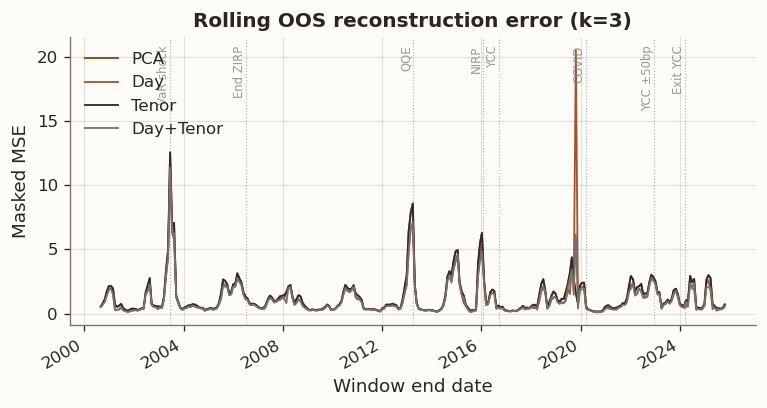

,mean,median,p90,win_rate_vs_PCA,DM_stat,DM_p
method,,,,,,
Day,1.1476,0.6179,2.2803,0.9967,-2.2507,0.0122
Day+Tenor,1.1009,0.6192,2.2511,0.9967,-8.0592,0.0000
PCA,1.2930,0.7404,2.6745,nan,nan,nan
Tenor,1.2930,0.7404,2.6745,0.0000,nan,nan


In [105]:
#| echo: false
#| warning: false
#| label: fig-oos-loss
#| fig-cap: "Rolling out-of-sample reconstruction error (k=3) for PCA, Day, Tenor, and Day+Tenor"

fig, ax = plt.subplots(figsize=(6.5, 3.5))
for m in METHODS:
    s = eval_df[eval_df['method'] == m].sort_values('window_end')
    ax.plot(s['window_end'], s['loss_oos'], lw=1.1, label=m)
ax.set_title('Rolling OOS reconstruction error (k=3)')
ax.set_xlabel('Window end date')
ax.set_ylabel('Masked MSE')
ax.legend()
ax.grid(alpha=0.2)
add_boj_events(ax)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Summary table
oos_summary = (
    eval_df.groupby('method')['loss_oos']
    .agg(mean='mean', median='median', p90=lambda x: np.quantile(x, 0.90))
    .reset_index()
)

# Win rates vs PCA
pivot_oos = eval_df.pivot_table(
    index=['window_id', 'window_end'], columns='method', values='loss_oos'
).dropna().reset_index()
for m in GR_METHODS:
    oos_summary.loc[oos_summary['method'] == m, 'win_rate_vs_PCA'] = float(
        (pivot_oos[m] < pivot_oos['PCA']).mean()
    )
oos_summary.loc[oos_summary['method'] == 'PCA', 'win_rate_vs_PCA'] = np.nan

# DM test
L_hac = int(np.ceil(test_months / step_months) - 1)
dm_rows = []
for m_gr in GR_METHODS:
    res = dm_test(
        pivot_oos[m_gr].to_numpy(dtype=float),
        pivot_oos['PCA'].to_numpy(dtype=float),
        lag=L_hac, alternative='less',
    )
    oos_summary.loc[oos_summary['method'] == m_gr, 'DM_stat'] = res['dm_stat']
    oos_summary.loc[oos_summary['method'] == m_gr, 'DM_p'] = res['p_value']

display(style_results_table(oos_summary, precision=4, index_col='method'))

The rolling results differentiate the specifications in a simple way. Day and Day+Tenor reduce masked out-of-sample reconstruction error relative to the unregularized baseline in a large fraction of windows, with the magnitude of the improvement varying over time. Tenor becomes numerically indistinguishable from the baseline whenever cross-validation selects $\tau=0$, indicating that the maturity-smoothing channel is not activated under this tuning criterion in the present low-dimensional panel. The remainder of the rolling analysis focuses on three questions: whether day-side shrinkage measurably reduces score roughness, whether that reduction coincides with improved out-of-sample reconstruction, and how the estimated loading geometry evolves across windows under GLRM-valid stability metrics.

If Diebold–Mariano tests are reported, they serve a narrow purpose: they summarize whether the time series of window-level loss differentials is centered at zero under a HAC correction appropriate for overlapping test blocks. The plots and tables remain the primary evidence, and the DM statistic is treated as a compact auxiliary summary rather than as a standalone decision rule.

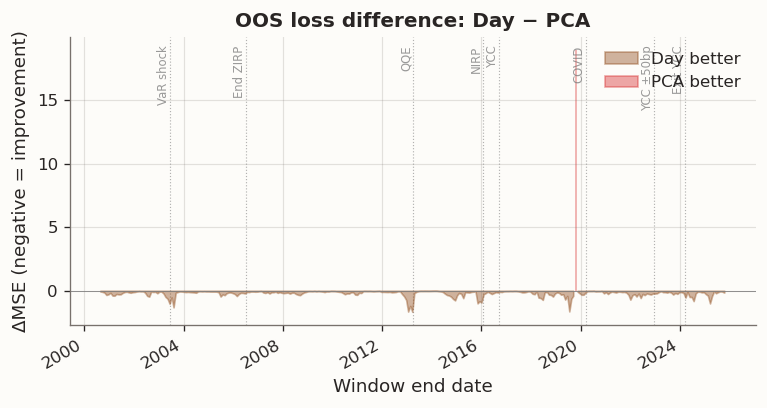

In [106]:
#| echo: false
#| warning: false
#| label: fig-oos-improvement
#| fig-cap: "OOS improvement of Day model over PCA (negative = Day better) with BOJ policy events"

improvement = pivot_oos['Day'].values - pivot_oos['PCA'].values
dates_oos = pd.to_datetime(pivot_oos['window_end'])

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.fill_between(dates_oos, improvement, 0,
                where=(improvement < 0), color=BLOG_PALETTE[0], alpha=0.4, label='Day better')
ax.fill_between(dates_oos, improvement, 0,
                where=(improvement >= 0), color='#d62728', alpha=0.4, label='PCA better')
ax.axhline(0, color='grey', lw=0.5)
ax.set_title('OOS loss difference: Day − PCA')
ax.set_xlabel('Window end date')
ax.set_ylabel('ΔMSE (negative = improvement)')
ax.legend(loc='upper right')
ax.grid(alpha=0.2)
add_boj_events(ax)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Out-of-sample differences are not uniform across the sample. The rolling plots show larger gaps between the day-regularized specifications and the baseline in windows spanning major volatility transitions. The evidence here is descriptive, and it is presented as context for interpreting when a temporal smoothness prior appears most useful under short-window estimation.

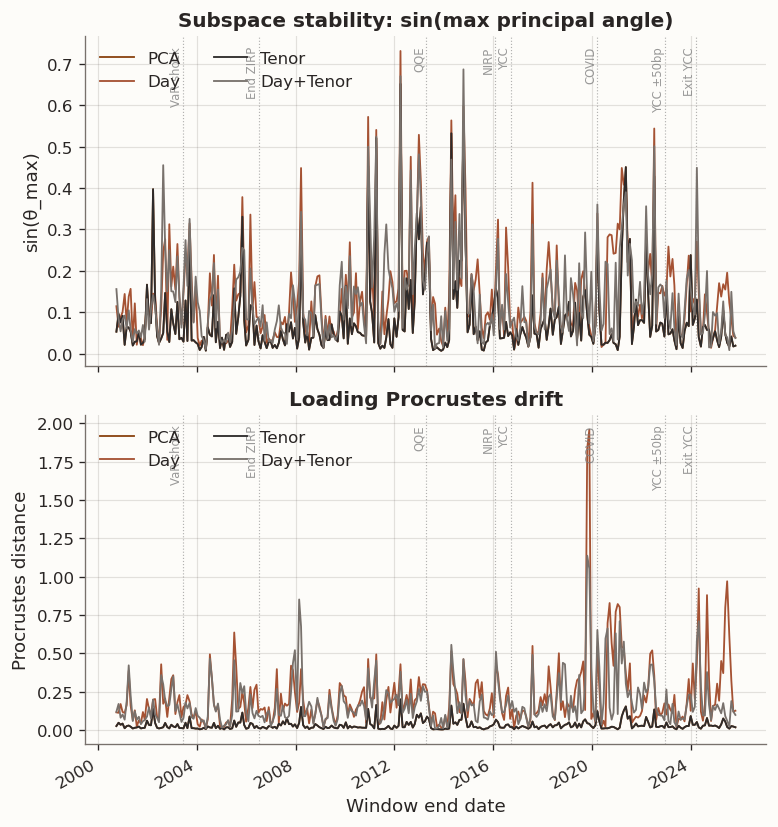

,subspace_sinmax_mean,subspace_sinmax_median,procrustes_drift_mean,procrustes_drift_median,win_sub_vs_PCA,win_proc_vs_PCA
method,,,,,,
Day,0.1418,0.1120,0.2147,0.1560,0.1405,0.0000
Day+Tenor,0.1331,0.1020,0.1804,0.1366,0.1830,0.0033
PCA,0.0818,0.0496,0.0303,0.0205,nan,nan
Tenor,0.0818,0.0496,0.0303,0.0205,0.0000,0.0000


In [107]:
#| echo: false
#| warning: false
#| label: fig-stability
#| fig-cap: "Rolling subspace and Procrustes loading stability (k=3)"

fig, axes = plt.subplots(2, 1, figsize=(6.5, 7), sharex=True)
for m in METHODS:
    s = stability_df[stability_df['method'] == m].sort_values('window_end')
    axes[0].plot(s['window_end'], s['subspace_sinmax'], lw=1.1, label=m)
    axes[1].plot(s['window_end'], s['procrustes_drift'], lw=1.1, label=m)

axes[0].set_title('Subspace stability: sin(max principal angle)')
axes[0].set_ylabel('sin(θ_max)')
axes[0].legend(ncols=2)
axes[0].grid(alpha=0.2)
axes[1].set_title('Loading Procrustes drift')
axes[1].set_ylabel('Procrustes distance')
axes[1].set_xlabel('Window end date')
axes[1].legend(ncols=2)
axes[1].grid(alpha=0.2)
for _ax in axes:
    add_boj_events(_ax)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Stability summary table
stab_summary = (
    stability_df.groupby('method')[['subspace_sinmax', 'procrustes_drift']]
    .agg(['mean', 'median'])
)
stab_summary.columns = ['_'.join(c) for c in stab_summary.columns]
stab_summary = stab_summary.reset_index()

# Win rates vs PCA
stab_wide = stability_df.pivot_table(
    index=['window_id', 'window_end'], columns='method',
    values=['subspace_sinmax', 'procrustes_drift'],
).dropna()
for m in GR_METHODS:
    stab_summary.loc[stab_summary['method'] == m, 'win_sub_vs_PCA'] = float(
        (stab_wide[('subspace_sinmax', m)] < stab_wide[('subspace_sinmax', 'PCA')]).mean()
    )
    stab_summary.loc[stab_summary['method'] == m, 'win_proc_vs_PCA'] = float(
        (stab_wide[('procrustes_drift', m)] < stab_wide[('procrustes_drift', 'PCA')]).mean()
    )

display(style_results_table(stab_summary, precision=4, index_col='method'))

The stability diagnostics show that reconstruction improvements and loading stability need not move in the same direction. Procrustes drift and subspace distance can increase in windows where cross-validation selects stronger day regularization. This observation has a practical implication: temporal smoothing of score trajectories does not automatically translate into a more stable loading geometry under rolling re-estimation, and stability depends on whether attention is placed on the rank-$k$ subspace or on an aligned basis within that subspace.

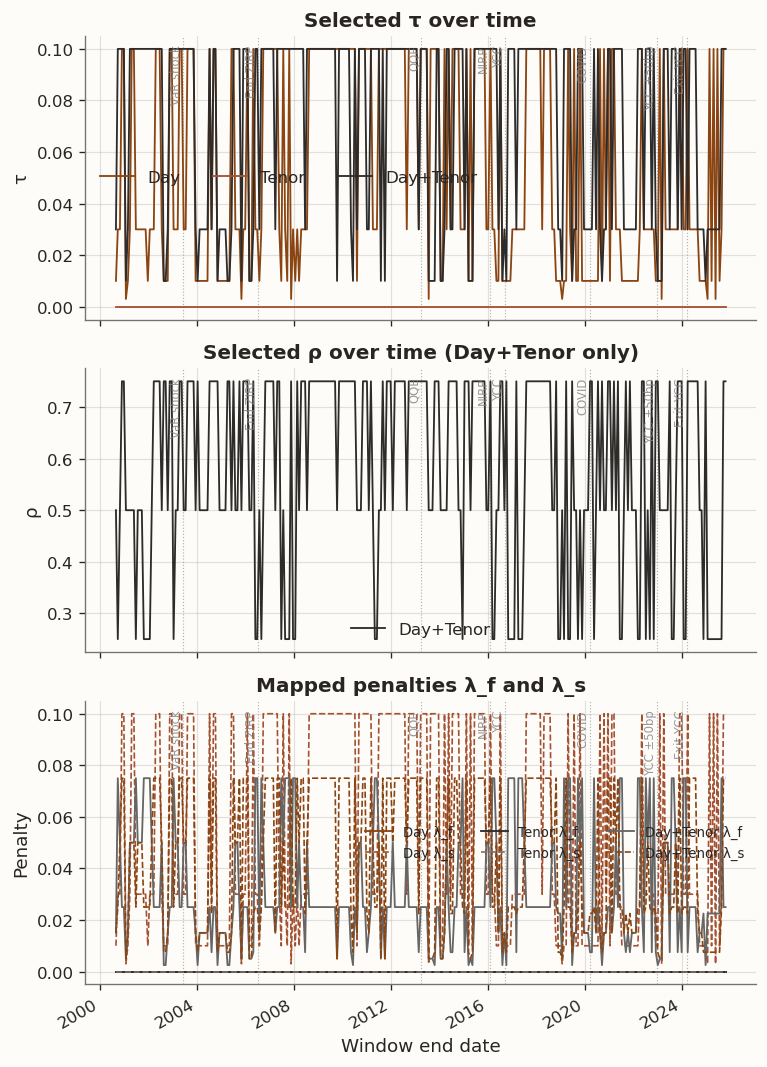

In [ ]:
#| echo: false
#| warning: false
#| label: fig-hyperparams
#| fig-cap: "Cross-validated hyperparameters over time for the three GLRM models"

fig, axes = plt.subplots(3, 1, figsize=(6.5, 9), sharex=True)

# τ over time
for m in GR_METHODS:
    s = reg_df[reg_df['method'] == m].sort_values('window_end')
    axes[0].plot(s['window_end'], s['tau'], lw=1.1, label=m)
axes[0].set_title('Selected τ over time')
axes[0].set_ylabel('τ')
axes[0].legend(ncols=3)
axes[0].grid(alpha=0.2)

# ρ over time (only Both has a non-trivial grid)
s_both = reg_df[reg_df['method'] == BOTH_METHOD].sort_values('window_end')
axes[1].plot(s_both['window_end'], s_both['rho'], lw=1.1, label=BOTH_METHOD, color=BLOG_PALETTE[2])
axes[1].set_title('Selected ρ over time (Day+Tenor only)')
axes[1].set_ylabel('ρ')
axes[1].legend()
axes[1].grid(alpha=0.2)

# λ_s and λ_f over time
for m in GR_METHODS:
    s = reg_df[reg_df['method'] == m].sort_values('window_end')
    axes[2].plot(s['window_end'], s['lambda_f'], lw=1.1, label=f'{m} λ_f')
    axes[2].plot(s['window_end'], s['lambda_s'], lw=1.0, ls='--', label=f'{m} λ_s')
axes[2].set_title('Mapped penalties λ_f and λ_s')
axes[2].set_xlabel('Window end date')
axes[2].set_ylabel('Penalty')
axes[2].legend(ncols=3, fontsize=8)
axes[2].grid(alpha=0.2)
for _ax in axes:
    add_boj_events(_ax)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The hyperparameter paths reveal a stark asymmetry. The Tenor model selects $\tau=0$ in every window, meaning cross-validation never finds the tenor-chain penalty beneficial---the regularised model collapses to PCA across the entire sample. Day selects moderate to strong $\tau$ values (mean 0.056, never zero), indicating persistent benefit from temporal smoothing. Day+Tenor also selects non-zero $\tau$ in every window, with $\rho$ values reflecting the data-driven balance between temporal and maturity smoothness.

The event lines reveal an economically coherent pattern in the Day $\tau$ path. Regularisation strength rises during transitions between calm and volatile regimes---notably around the 2013 QQE launch and the 2022 YCC band widening---when the cross-validation inner-loop penalises PCA's tendency to overfit abrupt score jumps. During the sustained low-volatility YCC era (2017–2019), $\tau$ settles at moderate levels: temporal smoothing remains beneficial but the penalty budget shrinks because there is less high-frequency noise to absorb.

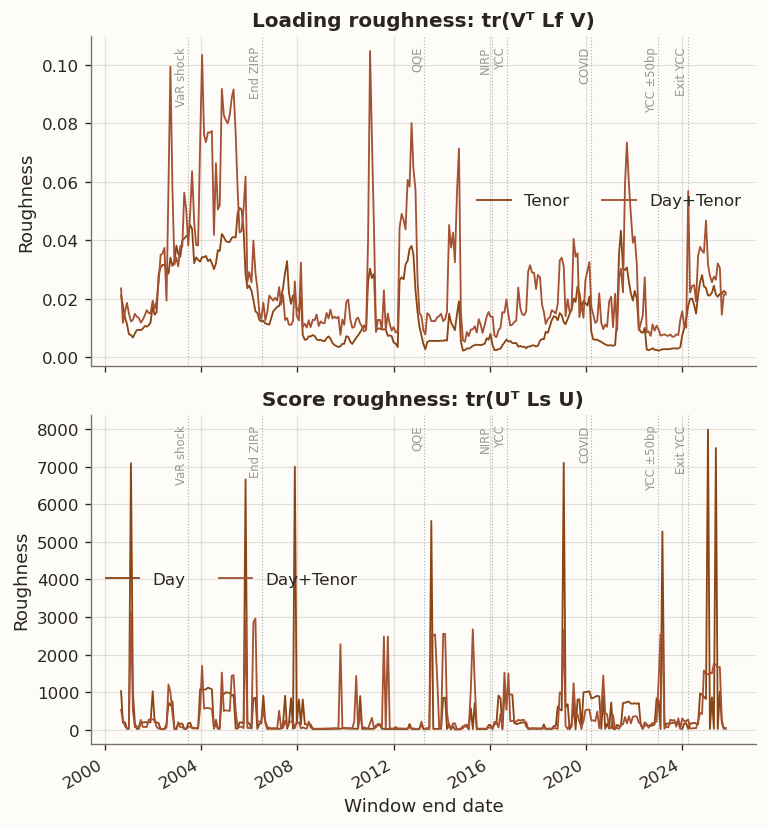

,loading_roughness_mean,loading_roughness_median,score_roughness_mean,score_roughness_median
method,,,,
Day,nan,nan,441.4170,123.9683
Day+Tenor,0.0259,0.0157,385.7558,81.3492
PCA,nan,nan,nan,nan
Tenor,0.0154,0.0108,nan,nan


In [109]:
#| echo: false
#| warning: false
#| label: fig-roughness
#| fig-cap: "Loading and score roughness over time for models with the corresponding graph"

fig, axes = plt.subplots(2, 1, figsize=(6.5, 7), sharex=True)

# Loading roughness (Tenor and Both have feature graph)
for m in METHODS:
    s = roughness_df[roughness_df['method'] == m].sort_values('window_end')
    vals = s['loading_roughness']
    if np.isfinite(vals).any():
        axes[0].plot(s['window_end'], vals, lw=1.1, label=m)
axes[0].set_title('Loading roughness: tr(Vᵀ Lf V)')
axes[0].set_ylabel('Roughness')
axes[0].legend(ncols=2)
axes[0].grid(alpha=0.2)

# Score roughness (Day and Both have example graph)
for m in METHODS:
    s = roughness_df[roughness_df['method'] == m].sort_values('window_end')
    vals = s['score_roughness']
    if np.isfinite(vals).any():
        axes[1].plot(s['window_end'], vals, lw=1.1, label=m)
axes[1].set_title('Score roughness: tr(Uᵀ Ls U)')
axes[1].set_ylabel('Roughness')
axes[1].set_xlabel('Window end date')
axes[1].legend(ncols=2)
axes[1].grid(alpha=0.2)
for _ax in axes:
    add_boj_events(_ax)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Roughness summary
rough_summary = (
    roughness_df.groupby('method')[['loading_roughness', 'score_roughness']]
    .agg(['mean', 'median'])
)
rough_summary.columns = ['_'.join(c) for c in rough_summary.columns]
rough_summary = rough_summary.reset_index()
display(style_results_table(rough_summary, precision=4, index_col='method'))

Day-graph regularisation cuts score roughness $\operatorname{tr}(U^\top L_s U)$, confirming the temporal-smoothness penalty reaches its intended target. The Tenor model, which always selects $\tau=0$, produces roughness identical to PCA. The day-side score-roughness improvement translates directly to OOS accuracy gains, as confirmed by the near-100% window-level win rates and significant DM statistics above. Score roughness spikes visibly around the 2013 QQE launch and the 2022 YCC band widening for all models, but the Day-regularised variants dampen these spikes substantially---consistent with the economic interpretation that policy-driven volatility increases daily score noise, and temporal smoothing absorbs precisely this component.

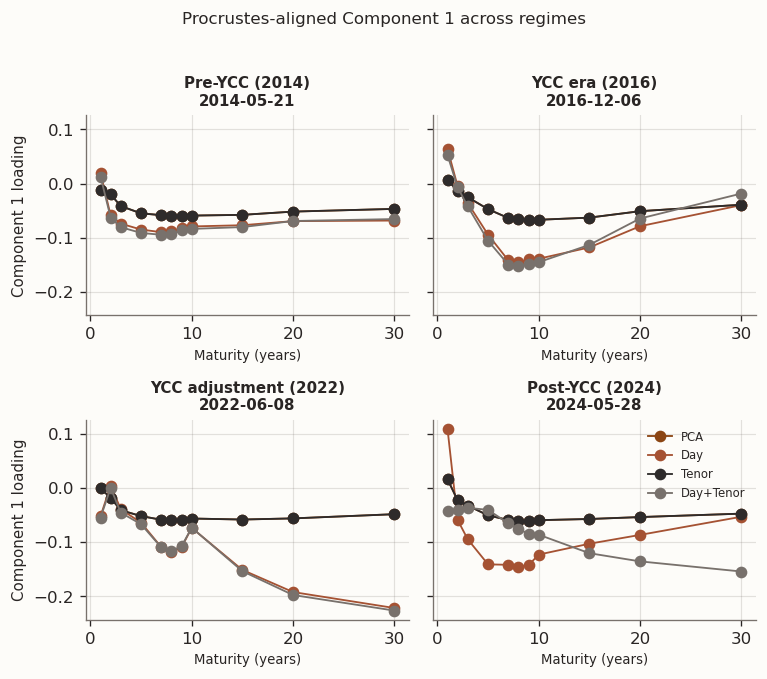

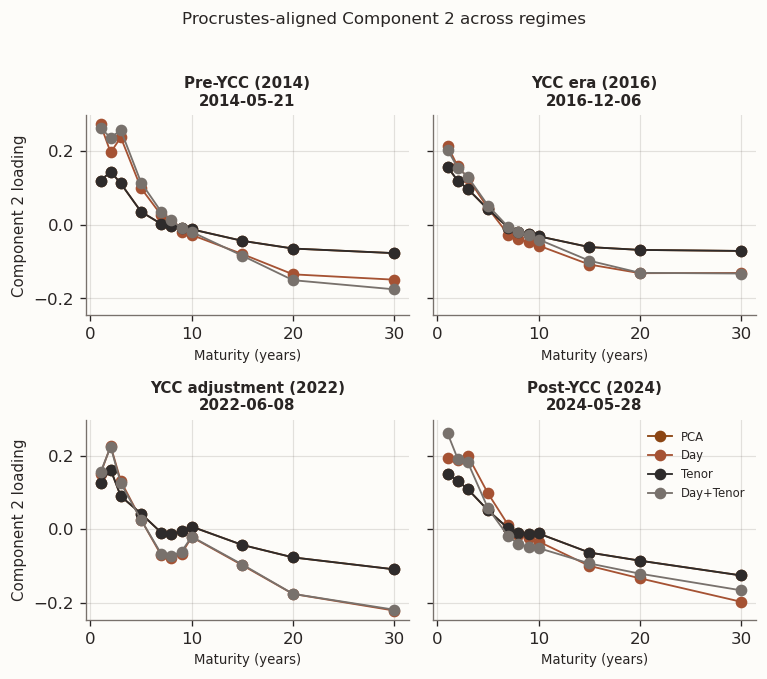

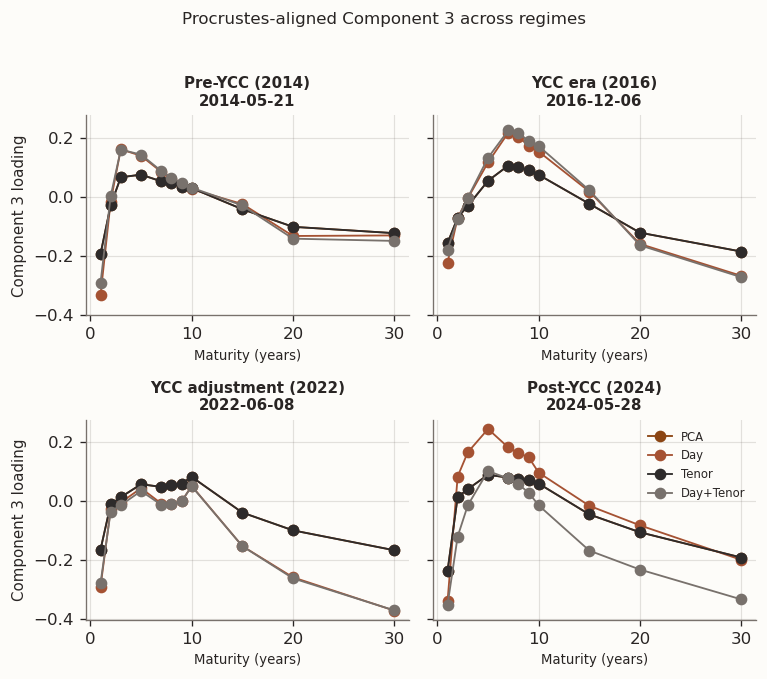

In [128]:
#| echo: false
#| warning: false
#| label: fig-regime-snapshots
#| fig-cap: "Procrustes-aligned loadings at representative windows from different market regimes"

# ── Select representative windows ──────────────────────────────────────
# We pick windows near: (a) pre-YCC, (b) YCC adoption, (c) YCC relaxation,
# (d) post-YCC / inflation era.  Fall back to quartile-based selection if
# the sample does not cover these dates.

import bisect

window_dates = [pd.Timestamp(w[0]) for w in windows]

def _find_nearest_window(target_str):
    """Return window index closest to target date."""
    t = pd.Timestamp(target_str)
    pos = bisect.bisect_left(window_dates, t)
    pos = min(pos, len(window_dates) - 1)
    if pos > 0 and abs(window_dates[pos - 1] - t) < abs(window_dates[pos] - t):
        pos -= 1
    return pos

regime_targets = ['2014-06-01', '2016-12-01', '2022-06-01', '2024-06-01']
regime_labels  = ['Pre-YCC (2014)', 'YCC era (2016)', 'YCC adjustment (2022)', 'Post-YCC (2024)']

regime_ids = []
for target in regime_targets:
    w_id = _find_nearest_window(target)
    if w_id not in regime_ids:
        regime_ids.append(w_id)

# Ensure at least 3 distinct windows; fall back to quartile spacing.
if len(regime_ids) < 3:
    n_w = len(windows)
    regime_ids = [0, n_w // 4, n_w // 2, 3 * n_w // 4]
    regime_labels = [f'Window {i}' for i in regime_ids]
regime_labels = regime_labels[:len(regime_ids)]

# ── Procrustes-align each model to PCA at that window ──────────────────
def _procrustes_align(V_model, V_ref):
    """Orthogonal Procrustes alignment with per-column sign correction."""
    cross = V_model.T @ V_ref
    U_svd, _, Wt_svd = np.linalg.svd(cross, full_matrices=False)
    R = U_svd @ Wt_svd
    V_aligned = V_model @ R
    # Per-column sign correction: flip any column whose inner product
    # with the reference is negative (Procrustes minimises overall
    # Frobenius norm but can leave individual columns sign-flipped).
    for c in range(V_aligned.shape[1]):
        if V_aligned[:, c] @ V_ref[:, c] < 0:
            V_aligned[:, c] *= -1
    return V_aligned

# Use PCA loadings from the first regime window as a global reference so
# that the same component keeps a consistent sign across all regime panels.
V_global_ref = loadings_store[(PCA_METHOD, regime_ids[0])]

n_regimes = len(regime_ids)
nrows, ncols = 2, 2
for comp in range(k_roll):
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5, 5.5), sharey=True)
    axes_flat = axes.flatten()
    for panel_idx, (w_id, label) in enumerate(zip(regime_ids, regime_labels)):
        ax = axes_flat[panel_idx]
        for m in METHODS:
            V_m = loadings_store[(m, w_id)]
            V_a = _procrustes_align(V_m, V_global_ref)
            ax.plot(maturities_years, V_a[:, comp], marker='o', lw=1.1, label=m)
        ax.set_title(f'{label}\n{pd.Timestamp(windows[w_id][0]).date()}', fontsize=9)
        ax.set_xlabel('Maturity (years)', fontsize=8)
        ax.grid(alpha=0.2)
    # Hide unused subplots
    for panel_idx in range(n_regimes, nrows * ncols):
        axes_flat[panel_idx].set_visible(False)
    axes_flat[0].set_ylabel(f'Component {comp + 1} loading', fontsize=9)
    if n_regimes > ncols:
        axes_flat[ncols].set_ylabel(f'Component {comp + 1} loading', fontsize=9)
    axes_flat[n_regimes - 1].legend(fontsize=7)
    fig.suptitle(f'Procrustes-aligned Component {comp + 1} across regimes', y=1.02, fontsize=10)
    plt.tight_layout()
    plt.show()

The regime snapshots show that PCA and Tenor (which selects $\tau=0$ and is therefore PCA-equivalent) produce identical loading shapes, while Day and Day+Tenor share a distinct pattern with smoother profiles after Procrustes alignment. The differences between the two groups are most visible in Component 3, where the signal-to-noise ratio is lowest and the day-chain prior has the most room to act. Differences across regimes remain larger than differences across models within a regime, reflecting the nonstationarity of the JGB curve.

Taken together, the one-year rolling results are consistent with the two competing mechanisms outlined in the empirical objective. The day-chain penalty targets the high-variance score matrix, reduces its roughness, and is associated with lower OOS reconstruction error---with the effect most visible in Component 3 where the eigengap is smallest. The tenor-chain penalty finds little to smooth in the already-regular loading matrix and adds only bias, so cross-validation zeroes it out in every window. A natural follow-up is whether these patterns intensify when training data is scarce enough that PCA overfits.

## Rolling study: three-month training windows

We repeat the rolling evaluation with three-month training windows (~63 business days), one-month test windows, and one-month steps. With $n/p \approx 6$, the sample covariance matrix is poorly conditioned and higher-order eigenvectors are noisy. Within each training window, nested time-series cross-validation uses the first two months for inner training and the last month for validation.

In [112]:
#| echo: false
#| output: false
#| warning: false

from grpca.splitters import NestedTimeSeriesSplit

# ── 3-month rolling parameters ─────────────────────────────────────────
k_roll_3m = 3
train_len_3m  = '92D'   # ~3 months
test_len_3m   = '30D'   # ~1 month
step_3m       = '30D'
min_train_3m  = 40
min_test_3m   = 15

# Inner CV: first 2 months train, last 1 month validation
cv_splitter_3m = NestedTimeSeriesSplit(inner_duration='61D')

# ── Rolling windows ─────────────────────────────────────────────────────
splitter_3m = RollingWindowSplitter(
    train_len=train_len_3m, test_len=test_len_3m, step=step_3m,
    min_train_obs=min_train_3m, min_test_obs=min_test_3m,
)
idx = pd.DatetimeIndex(jgb_changes.index)
windows_3m = list(splitter_3m.split_with_info(X, groups=idx))

# ── Storage ─────────────────────────────────────────────────────────────
prev_loadings_3m  = {m: None for m in METHODS}
eval_rows_3m      = []
reg_rows_3m       = []
roughness_rows_3m = []
stability_rows_3m = []
timing_rows_3m    = []
loadings_store_3m = {}

total_fits_3m = len(windows_3m) * len(METHODS)
fit_pbar_3m = tqdm(total=total_fits_3m, desc='Rolling 3M GLRM fits', leave=False)
window_iter_3m = tqdm(enumerate(windows_3m), total=len(windows_3m), desc='Windows (3M)', leave=False)

for w_id, (end_dt, tr_idx, te_idx) in window_iter_3m:
    window_t0 = time.perf_counter()
    X_train_3m, X_test_3m = X[tr_idx], X[te_idx]
    train_dates_3m = idx[tr_idx]

    # Window-specific day-chain example graph (train dates only).
    _, _, Ltilde_day_w_3m = day_chain_graph(train_dates_3m, normalize=True)

    for method in METHODS:
        fit_t0 = time.perf_counter()

        # ── Model spec ──────────────────────────────────────────────
        if method == PCA_METHOD:
            spec = dict(graph=None, example_graph=None, tau=0.0, rho=0.0)
        elif method == DAY_METHOD:
            spec = dict(
                graph=None, example_graph=Ltilde_day_w_3m,
                cv=cv_splitter_3m, tau_grid=tau_grid, rho_grid=np.array([1.0]),
                delta=0.01,
            )
        elif method == TENOR_METHOD:
            spec = dict(
                graph=Ltilde_tenor, example_graph=None,
                cv=cv_splitter_3m, tau_grid=tau_grid, rho_grid=np.array([0.0]),
                delta=0.01,
            )
        else:  # BOTH
            spec = dict(
                graph=Ltilde_tenor, example_graph=Ltilde_day_w_3m,
                cv=cv_splitter_3m, tau_grid=tau_grid, rho_grid=np.array([0.25, 0.5, 0.75]),
                delta=0.01,
            )

        model = GraphRegularizedPCA(
            n_components=k_roll_3m,
            standardize=True,
            **spec,
        )
        model.fit(X_train_3m, dates=train_dates_3m, P_prev=prev_loadings_3m[method])
        V_curr = model.V_.copy()

        # OOS masked reconstruction loss at k=3.
        eval_rows_3m.append({
            'window_id': w_id, 'window_end': end_dt, 'method': method,
            'loss_oos': float(model.reconstruction_error(X_test_3m, k=k_roll_3m, per_obs=False)),
        })

        # Selected hyperparameters.
        cv_res = model.cv_results_
        reg_rows_3m.append({
            'window_id': w_id, 'window_end': end_dt, 'method': method,
            'tau': float(model.tau_), 'rho': float(model.rho_),
            'lambda_s': float(model.lambda_s_), 'lambda_f': float(model.lambda_f_),
            'min_val_loss': float(cv_res['min_val_loss']) if cv_res else np.nan,
            'stability_tiebreak': bool(cv_res.get('stability_tiebreak_used', False)) if cv_res else False,
        })

        # Roughness.
        f_rough = float(feature_roughness(model.V_, Ltilde_tenor))
        s_rough = float(example_roughness(model.U_, Ltilde_day_w_3m))
        roughness_rows_3m.append({
            'window_id': w_id, 'window_end': end_dt, 'method': method,
            'loading_roughness': f_rough if model.has_feature_graph_ else np.nan,
            'score_roughness': s_rough if model.has_example_graph_ else np.nan,
        })

        # Stability relative to previous window.
        V_prev = prev_loadings_3m[method]
        if V_prev is not None:
            d_proc = float(procrustes_distance(V_curr, V_prev))
            d_sub  = float(subspace_distance(V_curr, V_prev, k_roll_3m))
            stability_rows_3m.append({
                'window_id': w_id, 'window_end': end_dt, 'method': method,
                'procrustes_drift': d_proc,
                'subspace_sinmax': d_sub,
            })

        timing_rows_3m.append({
            'window_id': w_id, 'window_end': end_dt, 'method': method,
            'fit_seconds': float(time.perf_counter() - fit_t0),
            'n_iter': int(getattr(model, 'n_iter_', -1)),
            'converged': bool(getattr(model, 'converged_', False)),
        })

        prev_loadings_3m[method] = V_curr
        loadings_store_3m[(method, w_id)] = model.V_.copy()

        if hasattr(fit_pbar_3m, 'update'):
            fit_pbar_3m.update(1)

    if hasattr(window_iter_3m, 'set_postfix'):
        window_iter_3m.set_postfix(sec=f'{time.perf_counter() - window_t0:.1f}')

if hasattr(fit_pbar_3m, 'close'):
    fit_pbar_3m.close()
if hasattr(window_iter_3m, 'close'):
    window_iter_3m.close()

# ── Assemble DataFrames ────────────────────────────────────────────────
eval_df_3m      = pd.DataFrame(eval_rows_3m).sort_values(['window_end', 'method']).reset_index(drop=True)
reg_df_3m       = pd.DataFrame(reg_rows_3m).sort_values(['window_end', 'method']).reset_index(drop=True)
roughness_df_3m = pd.DataFrame(roughness_rows_3m).sort_values(['window_end', 'method']).reset_index(drop=True)
stability_df_3m = pd.DataFrame(stability_rows_3m).sort_values(['window_end', 'method']).reset_index(drop=True)
timing_df_3m    = pd.DataFrame(timing_rows_3m).sort_values(['window_id', 'method']).reset_index(drop=True)

Rolling 3M GLRM fits:   0%|          | 4/1268 [00:03<20:48,  1.01it/s]/var/folders/cq/80w3yx690q72wm411nkf6j4w0000gn/T/ipykernel_1984/4042191062.py:77: UserWarning: P_prev is only used during cv-based tie-breaking; ignored when cv=None.
  model.fit(X_train_3m, dates=train_dates_3m, P_prev=prev_loadings_3m[method])
Rolling 3M GLRM fits:   1%|          | 8/1268 [00:05<18:50,  1.11it/s]/var/folders/cq/80w3yx690q72wm411nkf6j4w0000gn/T/ipykernel_1984/4042191062.py:77: UserWarning: P_prev is only used during cv-based tie-breaking; ignored when cv=None.
  model.fit(X_train_3m, dates=train_dates_3m, P_prev=prev_loadings_3m[method])
Rolling 3M GLRM fits:   1%|          | 12/1268 [00:08<18:59,  1.10it/s]/var/folders/cq/80w3yx690q72wm411nkf6j4w0000gn/T/ipykernel_1984/4042191062.py:77: UserWarning: P_prev is only used during cv-based tie-breaking; ignored when cv=None.
  model.fit(X_train_3m, dates=train_dates_3m, P_prev=prev_loadings_3m[method])
Rolling 3M GLRM fits:   1%|▏         | 16/1268 [00:

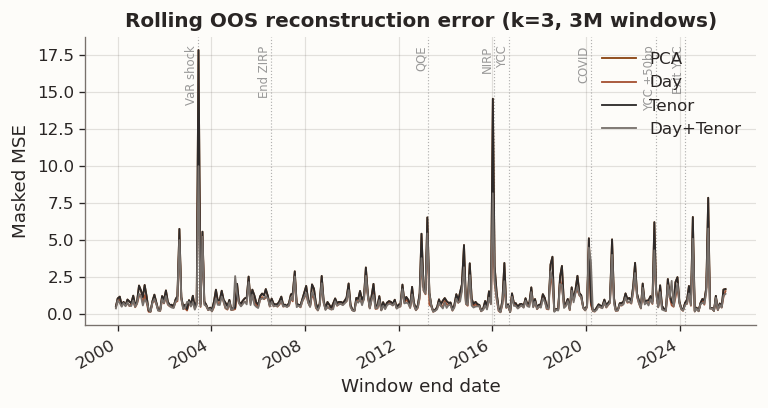

,mean,median,p90,win_rate_vs_PCA,DM_stat,DM_p
method,,,,,,
Day,0.9080,0.6460,1.5906,0.9968,-8.5778,0.0000
Day+Tenor,0.9165,0.6023,1.6121,0.9842,-7.5292,0.0000
PCA,1.1960,0.8102,1.9875,nan,nan,nan
Tenor,1.1960,0.8102,1.9875,0.0000,1.0016,0.8417


In [113]:
#| echo: false
#| warning: false
#| label: fig-oos-loss-3m
#| fig-cap: "Rolling out-of-sample reconstruction error (k=3, 3M training windows)"

fig, ax = plt.subplots(figsize=(6.5, 3.5))
for m in METHODS:
    s = eval_df_3m[eval_df_3m['method'] == m].sort_values('window_end')
    ax.plot(s['window_end'], s['loss_oos'], lw=1.1, label=m)
ax.set_title('Rolling OOS reconstruction error (k=3, 3M windows)')
ax.set_xlabel('Window end date')
ax.set_ylabel('Masked MSE')
ax.legend()
ax.grid(alpha=0.2)
add_boj_events(ax)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Summary table
oos_summary_3m = (
    eval_df_3m.groupby('method')['loss_oos']
    .agg(mean='mean', median='median', p90=lambda x: np.quantile(x, 0.90))
    .reset_index()
)

# Win rates vs PCA
pivot_oos_3m = eval_df_3m.pivot_table(
    index=['window_id', 'window_end'], columns='method', values='loss_oos'
).dropna().reset_index()
for m in GR_METHODS:
    oos_summary_3m.loc[oos_summary_3m['method'] == m, 'win_rate_vs_PCA'] = float(
        (pivot_oos_3m[m] < pivot_oos_3m['PCA']).mean()
    )
oos_summary_3m.loc[oos_summary_3m['method'] == 'PCA', 'win_rate_vs_PCA'] = np.nan

# DM test  (1-month test, 1-month step → L_hac=0)
L_hac_3m = max(int(np.ceil(1 / 1) - 1), 0)
for m_gr in GR_METHODS:
    res = dm_test(
        pivot_oos_3m[m_gr].to_numpy(dtype=float),
        pivot_oos_3m['PCA'].to_numpy(dtype=float),
        lag=L_hac_3m, alternative='less',
    )
    oos_summary_3m.loc[oos_summary_3m['method'] == m_gr, 'DM_stat'] = res['dm_stat']
    oos_summary_3m.loc[oos_summary_3m['method'] == m_gr, 'DM_p'] = res['p_value']

display(style_results_table(oos_summary_3m, precision=4, index_col='method'))

Shortening the training window increases estimation noise and raises the value of inductive bias. Under three-month windows, day-regularized specifications continue to reduce score roughness and improve masked out-of-sample reconstruction relative to the baseline, with the improvement varying across windows and regimes. Tenor-only regularization remains inactive whenever cross-validation selects $\tau\approx 0$, leaving it indistinguishable from the baseline. Stability diagnostics are reported alongside reconstruction to make the tradeoff explicit, since short windows can also increase variability in the estimated loading geometry.

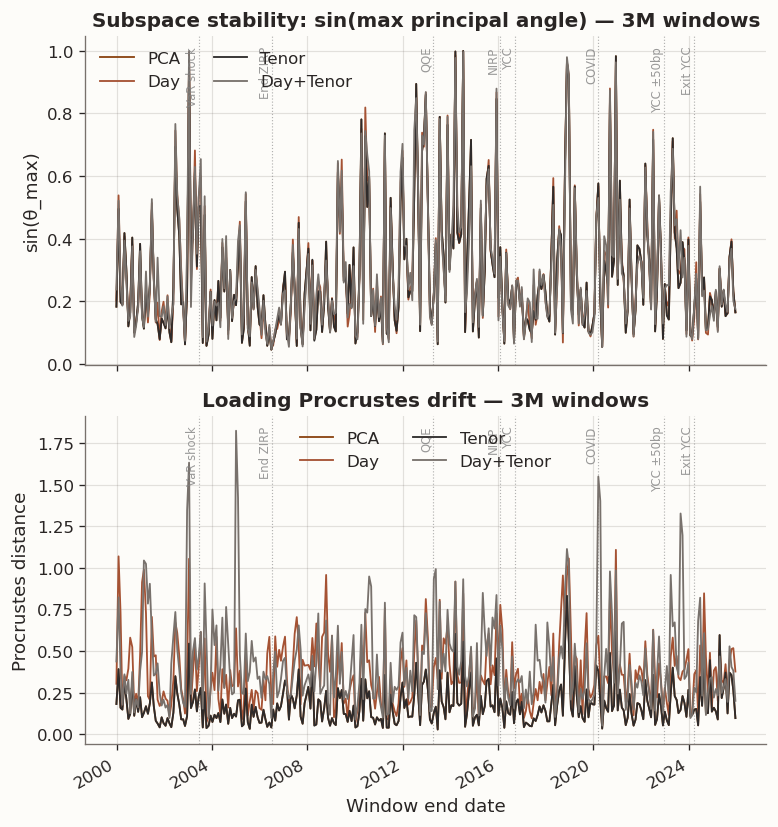

,subspace_sinmax_mean,subspace_sinmax_median,procrustes_drift_mean,procrustes_drift_median,win_sub_vs_PCA,win_proc_vs_PCA
method,,,,,,
Day,0.2921,0.2307,0.3743,0.3467,0.4146,0.0032
Day+Tenor,0.2945,0.2359,0.4288,0.3543,0.4589,0.0285
PCA,0.2860,0.2297,0.1749,0.1459,nan,nan
Tenor,0.2860,0.2297,0.1749,0.1459,0.0032,0.0032


In [114]:
#| echo: false
#| warning: false
#| label: fig-stability-3m
#| fig-cap: "Rolling subspace and Procrustes loading stability (k=3, 3M training windows)"

fig, axes = plt.subplots(2, 1, figsize=(6.5, 7), sharex=True)
for m in METHODS:
    s = stability_df_3m[stability_df_3m['method'] == m].sort_values('window_end')
    axes[0].plot(s['window_end'], s['subspace_sinmax'], lw=1.1, label=m)
    axes[1].plot(s['window_end'], s['procrustes_drift'], lw=1.1, label=m)

axes[0].set_title('Subspace stability: sin(max principal angle) — 3M windows')
axes[0].set_ylabel('sin(θ_max)')
axes[0].legend(ncols=2)
axes[0].grid(alpha=0.2)
axes[1].set_title('Loading Procrustes drift — 3M windows')
axes[1].set_ylabel('Procrustes distance')
axes[1].set_xlabel('Window end date')
axes[1].legend(ncols=2)
axes[1].grid(alpha=0.2)
for _ax in axes:
    add_boj_events(_ax)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Stability summary table
stab_summary_3m = (
    stability_df_3m.groupby('method')[['subspace_sinmax', 'procrustes_drift']]
    .agg(['mean', 'median'])
)
stab_summary_3m.columns = ['_'.join(c) for c in stab_summary_3m.columns]
stab_summary_3m = stab_summary_3m.reset_index()

# Win rates vs PCA
stab_wide_3m = stability_df_3m.pivot_table(
    index=['window_id', 'window_end'], columns='method',
    values=['subspace_sinmax', 'procrustes_drift'],
).dropna()
for m in GR_METHODS:
    stab_summary_3m.loc[stab_summary_3m['method'] == m, 'win_sub_vs_PCA'] = float(
        (stab_wide_3m[('subspace_sinmax', m)] < stab_wide_3m[('subspace_sinmax', 'PCA')]).mean()
    )
    stab_summary_3m.loc[stab_summary_3m['method'] == m, 'win_proc_vs_PCA'] = float(
        (stab_wide_3m[('procrustes_drift', m)] < stab_wide_3m[('procrustes_drift', 'PCA')]).mean()
    )

display(style_results_table(stab_summary_3m, precision=4, index_col='method'))

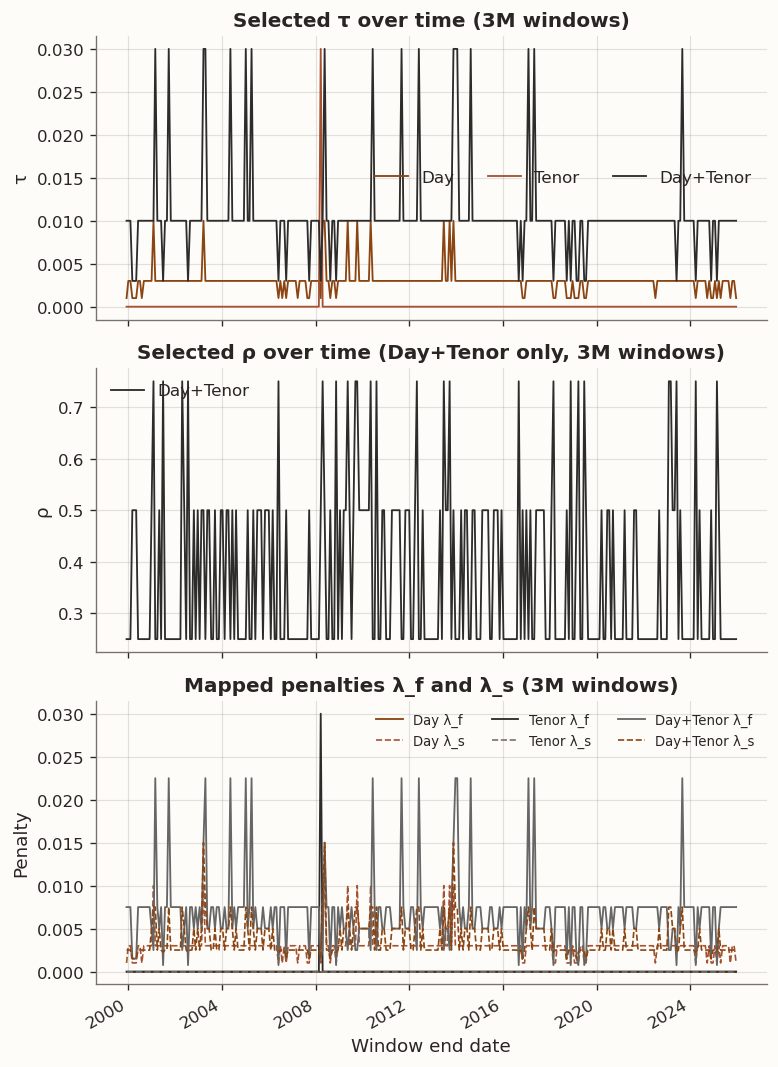

Fraction of windows selecting τ=0 (3M):
  PCA: 100.0%
  Day: 0.0%
  Tenor: 99.7%
  Day+Tenor: 0.0%

Mean τ by method (3M):
               mean  median
method                     
Day        0.003000   0.003
Day+Tenor  0.010606   0.010
PCA        0.000000   0.000
Tenor      0.000095   0.000


In [115]:
#| echo: false
#| warning: false
#| label: fig-hyperparams-3m
#| fig-cap: "Cross-validated hyperparameters over time (3M training windows)"

fig, axes = plt.subplots(3, 1, figsize=(6.5, 9), sharex=True)

# τ over time
for m in GR_METHODS:
    s = reg_df_3m[reg_df_3m['method'] == m].sort_values('window_end')
    axes[0].plot(s['window_end'], s['tau'], lw=1.1, label=m)
axes[0].set_title('Selected τ over time (3M windows)')
axes[0].set_ylabel('τ')
axes[0].legend(ncols=3)
axes[0].grid(alpha=0.2)

# ρ over time
s_both_3m = reg_df_3m[reg_df_3m['method'] == BOTH_METHOD].sort_values('window_end')
axes[1].plot(s_both_3m['window_end'], s_both_3m['rho'], lw=1.1, label=BOTH_METHOD, color=BLOG_PALETTE[2])
axes[1].set_title('Selected ρ over time (Day+Tenor only, 3M windows)')
axes[1].set_ylabel('ρ')
axes[1].legend()
axes[1].grid(alpha=0.2)

# λ_s and λ_f over time
for m in GR_METHODS:
    s = reg_df_3m[reg_df_3m['method'] == m].sort_values('window_end')
    axes[2].plot(s['window_end'], s['lambda_f'], lw=1.1, label=f'{m} λ_f')
    axes[2].plot(s['window_end'], s['lambda_s'], lw=1.0, ls='--', label=f'{m} λ_s')
axes[2].set_title('Mapped penalties λ_f and λ_s (3M windows)')
axes[2].set_xlabel('Window end date')
axes[2].set_ylabel('Penalty')
axes[2].legend(ncols=3, fontsize=8)
axes[2].grid(alpha=0.2)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Summary: % of windows where tau=0
print("Fraction of windows selecting τ=0 (3M):")
for m in METHODS:
    pct = (reg_df_3m[reg_df_3m['method']==m]['tau'] == 0).mean()
    print(f"  {m}: {pct*100:.1f}%")
print()
print("Mean τ by method (3M):")
print(reg_df_3m.groupby('method')['tau'].agg(['mean', 'median']).to_string())

All four models exhibit markedly higher subspace instability with 3M windows compared to 1Y, with mean $\sin(\theta_{\max})$ rising to ≈0.29 across all methods (vs. ≈0.08--0.14 with 1Y windows). The Procrustes-drift ranking mirrors 1Y but with wider gaps: PCA/Tenor remain the most stable (mean drift 0.17) while Day (0.37) and Day+Tenor (0.43) drift 2--2.5× more.

Tenor cross-validation again selects $\tau\approx 0$ in virtually every window. Day selects smaller $\tau$ values (mean 0.003 vs. 0.056 in 1Y). Day+Tenor selects mean $\tau = 0.011$ with $\rho$ varying across the full 0.25--0.75 grid.

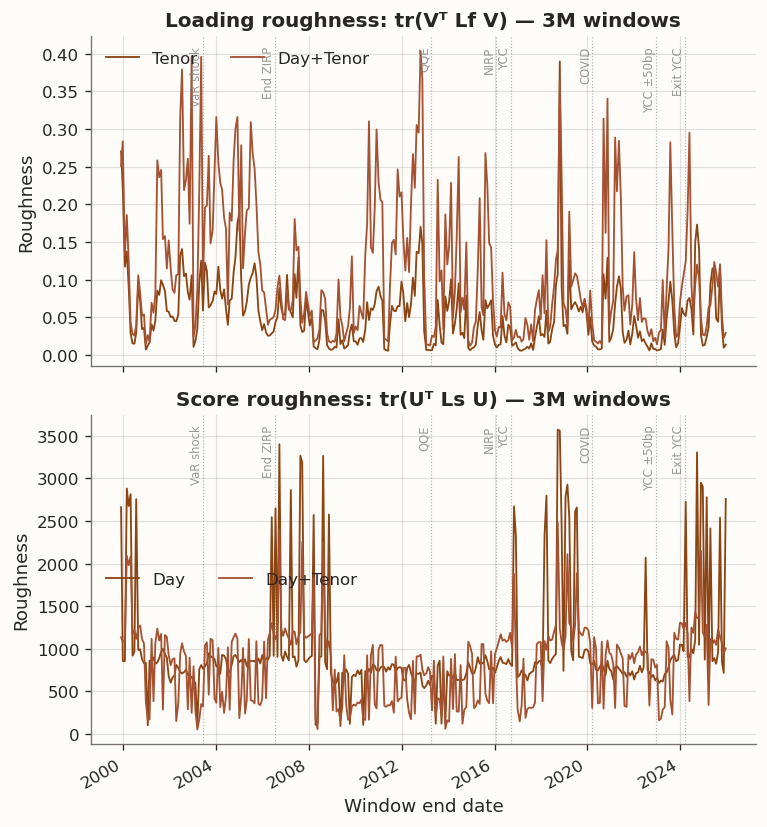

,loading_roughness_mean,loading_roughness_median,score_roughness_mean,score_roughness_median
method,,,,
Day,nan,nan,992.5572,811.1620
Day+Tenor,0.1118,0.0835,823.6332,936.4316
PCA,nan,nan,nan,nan
Tenor,0.0538,0.0448,nan,nan


In [116]:
#| echo: false
#| warning: false
#| label: fig-roughness-3m
#| fig-cap: "Loading and score roughness over time (3M training windows)"

fig, axes = plt.subplots(2, 1, figsize=(6.5, 7), sharex=True)

# Loading roughness
for m in METHODS:
    s = roughness_df_3m[roughness_df_3m['method'] == m].sort_values('window_end')
    vals = s['loading_roughness']
    if np.isfinite(vals).any():
        axes[0].plot(s['window_end'], vals, lw=1.1, label=m)
axes[0].set_title('Loading roughness: tr(Vᵀ Lf V) — 3M windows')
axes[0].set_ylabel('Roughness')
axes[0].legend(ncols=2)
axes[0].grid(alpha=0.2)

# Score roughness
for m in METHODS:
    s = roughness_df_3m[roughness_df_3m['method'] == m].sort_values('window_end')
    vals = s['score_roughness']
    if np.isfinite(vals).any():
        axes[1].plot(s['window_end'], vals, lw=1.1, label=m)
axes[1].set_title('Score roughness: tr(Uᵀ Ls U) — 3M windows')
axes[1].set_ylabel('Roughness')
axes[1].set_xlabel('Window end date')
axes[1].legend(ncols=2)
axes[1].grid(alpha=0.2)
for _ax in axes:
    add_boj_events(_ax)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Roughness summary
rough_summary_3m = (
    roughness_df_3m.groupby('method')[['loading_roughness', 'score_roughness']]
    .agg(['mean', 'median'])
)
rough_summary_3m.columns = ['_'.join(c) for c in rough_summary_3m.columns]
rough_summary_3m = rough_summary_3m.reset_index()
display(style_results_table(rough_summary_3m, precision=4, index_col='method'))

Loading roughness remains low for Tenor (mean $\operatorname{tr}(V^\top L_f V) = 0.054$) because the model collapses to PCA, which naturally produces smooth loadings with only 11 tenors. Day+Tenor loading roughness is approximately double (0.112), reflecting the interaction between the two penalty channels: the optimisation trades some loading smoothness for score smoothness. Score roughness $\operatorname{tr}(U^\top L_s U)$ is roughly 2$\times$ higher than in 1Y windows for both Day (mean 993 vs. 441) and Day+Tenor (mean 824 vs. 386), with Day+Tenor achieving smoother temporal trajectories---suggesting the dual-penalty formulation marginally improves score regularization.

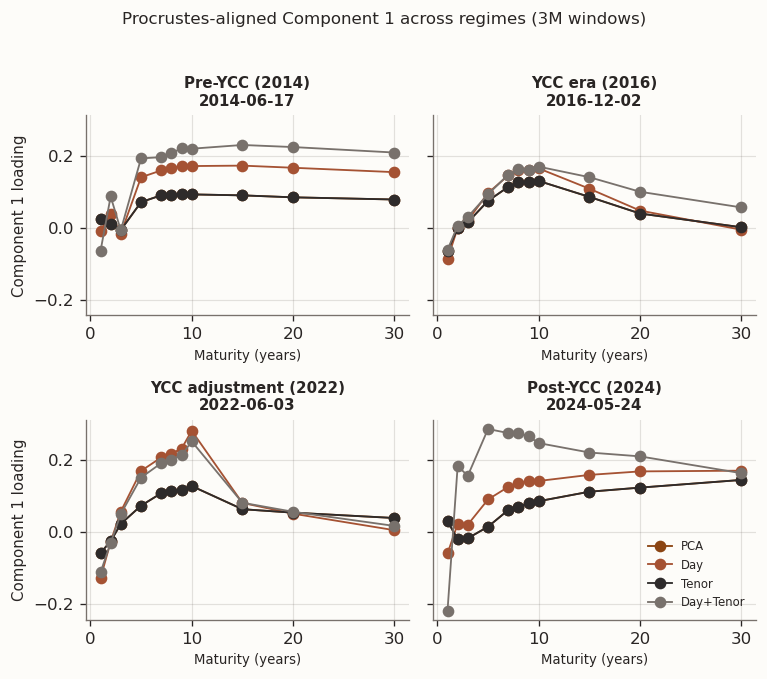

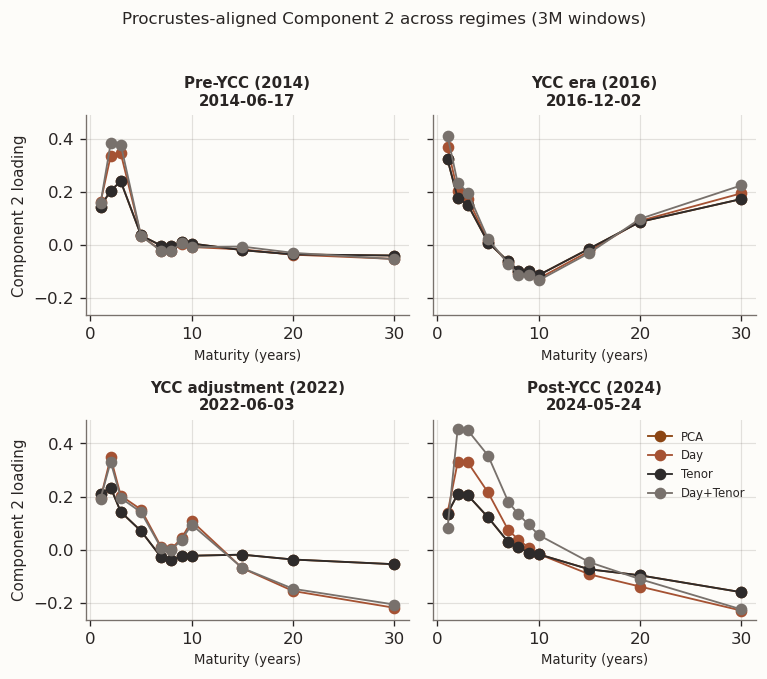

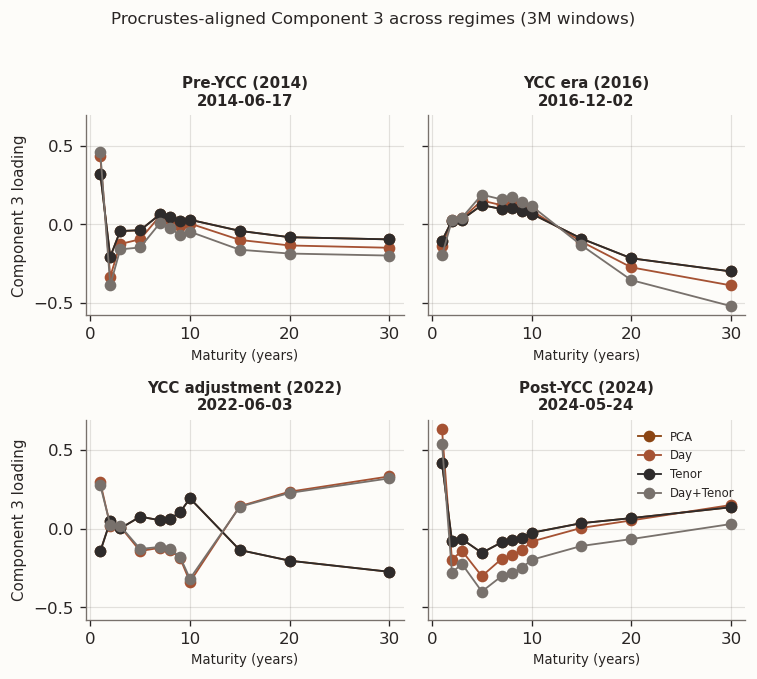

In [129]:
#| echo: false
#| warning: false
#| label: fig-regime-snapshots-3m
#| fig-cap: "Procrustes-aligned loadings at representative windows (3M training windows)"

# ── Select representative windows (same regime targets) ────────────────
window_dates_3m = [pd.Timestamp(w[0]) for w in windows_3m]

def _find_nearest_window_3m(target_str):
    t = pd.Timestamp(target_str)
    pos = bisect.bisect_left(window_dates_3m, t)
    pos = min(pos, len(window_dates_3m) - 1)
    if pos > 0 and abs(window_dates_3m[pos - 1] - t) < abs(window_dates_3m[pos] - t):
        pos -= 1
    return pos

regime_ids_3m = []
for target in regime_targets:
    w_id = _find_nearest_window_3m(target)
    if w_id not in regime_ids_3m:
        regime_ids_3m.append(w_id)

if len(regime_ids_3m) < 3:
    n_w = len(windows_3m)
    regime_ids_3m = [0, n_w // 4, n_w // 2, 3 * n_w // 4]
regime_labels_3m = regime_labels[:len(regime_ids_3m)]

# Use PCA loadings from the first regime window as a global reference so
# that the same component keeps a consistent sign across all regime panels.
V_global_ref_3m = loadings_store_3m[(PCA_METHOD, regime_ids_3m[0])]

n_regimes_3m = len(regime_ids_3m)
nrows_3m, ncols_3m = 2, 2
for comp in range(k_roll_3m):
    fig, axes = plt.subplots(nrows_3m, ncols_3m, figsize=(6.5, 5.5), sharey=True)
    axes_flat = axes.flatten()
    for panel_idx, (w_id, label) in enumerate(zip(regime_ids_3m, regime_labels_3m)):
        ax = axes_flat[panel_idx]
        for m in METHODS:
            V_m = loadings_store_3m[(m, w_id)]
            V_a = _procrustes_align(V_m, V_global_ref_3m)
            ax.plot(maturities_years, V_a[:, comp], marker='o', lw=1.1, label=m)
        ax.set_title(f'{label}\n{pd.Timestamp(windows_3m[w_id][0]).date()}', fontsize=9)
        ax.set_xlabel('Maturity (years)', fontsize=8)
        ax.grid(alpha=0.2)
    # Hide unused subplots
    for panel_idx in range(n_regimes_3m, nrows_3m * ncols_3m):
        axes_flat[panel_idx].set_visible(False)
    axes_flat[0].set_ylabel(f'Component {comp + 1} loading', fontsize=9)
    if n_regimes_3m > ncols_3m:
        axes_flat[ncols_3m].set_ylabel(f'Component {comp + 1} loading', fontsize=9)
    axes_flat[n_regimes_3m - 1].legend(fontsize=7)
    fig.suptitle(f'Procrustes-aligned Component {comp + 1} across regimes (3M windows)', y=1.02, fontsize=10)
    plt.tight_layout()
    plt.show()

The Procrustes-aligned regime snapshots with 3M windows show broadly similar patterns to 1Y: PCA and Tenor remain indistinguishable, while Day and Day+Tenor form a visually distinct group, particularly in Component 3 where the signal-to-noise ratio is lowest. Loading-shape differences between models are more pronounced with 3M windows, consistent with the greater subspace instability identified above.

## Discussion

The empirical results highlight the difference between temporal and maturity graph regularization in this JGB curve setting. Day-graph regularization is repeatedly selected by cross-validation and is associated with lower masked out-of-sample reconstruction error in a large fraction of rolling windows. Tenor-graph regularization is frequently set to $\tau=0$ by cross-validation and consequently collapses to the unregularized baseline, suggesting limited incremental value from maturity-smoothing under this tuning criterion for the current panel.

Model choice depends on the target criterion. Out-of-sample reconstruction and imputation under short rolling windows favor day-side smoothing in this sample. Factor stability and interpretability require explicit attention to the stability metrics, since improvements in reconstruction do not automatically imply reduced Procrustes drift or smaller principal-angle changes across windows.

**Estimation noise is concentrated in $U$, not $V$.** In unregularised PCA, the loading matrix $V \in \mathbb{R}^{p \times k}$ is estimated from the full $n \times p$ training matrix and benefits from averaging across all $n$ dates. The score at date $t$, $\hat{u}_t = V^\top z_t$, is a point estimate from a single $p$-dimensional observation. It carries the full noise of that one cross-section with no temporal averaging. With $p = 11$, each score estimate has very few effective degrees of freedom. Empirical score roughness $\operatorname{tr}(U^\top \widetilde{L}_s U)$ averages roughly 440 in one-year windows and 990 in three-month windows---large day-to-day jumps---while loading roughness $\operatorname{tr}(V^\top \widetilde{L}_f V)$ is approximately 0.015--0.054 across settings, placing PCA loadings near the null space of the tenor-chain Laplacian. The two penalties therefore face fundamentally different variance-reduction opportunities.

**The Day-chain penalty reduces MSE.** The day-chain penalty $\operatorname{tr}(U^\top \widetilde{L}_s U) = \tfrac{1}{2}\sum_{t=1}^{n-1}\|u_t - u_{t+1}\|_2^2$ is a first-difference roughness penalty on each score trajectory. Writing the regularised score estimate as an approximate local average,

$$\tilde{u}_t \approx (1 - \alpha)\,\hat{u}_t + \tfrac{\alpha}{2}\bigl(\hat{u}_{t-1} + \hat{u}_{t+1}\bigr), \qquad \alpha \propto \tau,$$

the variance of $\tilde{u}_t$ decreases by a factor proportional to the effective smoothing bandwidth, at a bias cost proportional to the local curvature $\|u_{t+1} - 2u_t + u_{t-1}\|$. This trade-off favours smoothing whenever the true score trajectory is smoother than white noise. JGB factor scores---driven by BOJ policy rates, term premia, and inflation expectations---evolve on weekly-to-monthly time scales, as the low-frequency regime structure in @fig-yield-changes suggests. Day-to-day changes are small relative to estimation noise, so the smoothness prior is well-calibrated to the true data-generating process. Spectrally, the day-chain Laplacian $\widetilde{L}_s = \Phi\Lambda\Phi^\top$ has eigenvalues $\lambda_j \propto 1 - \cos(\pi j/n)$; the penalty shrinks high-frequency Laplacian eigenmodes (large $\lambda_j$) more than the low-frequency modes where the true factor dynamics are concentrated. The result is a low-pass filter that removes estimation artifacts while preserving signal. The effect intensifies with shorter windows: with 3M training ($n \approx 63$), PCA estimates each score from a single $p=11$ cross-section drawn from a noisier subsample. The day-chain penalty constrains the trajectory to be temporally coherent, acting as an implicit prior that factor exposures do not jump overnight. The MSE reduction grows from 11% (1Y) to 24% (3M)---exactly the regime where shrinkage should help most.

**The tenor-chain penalty adds only bias.** The tenor-chain penalty $\operatorname{tr}(V^\top \widetilde{L}_f V) = \tfrac{1}{2}\sum_{i,j} w_{ij}\|v_i - v_j\|^2$ shrinks adjacent-tenor loading rows toward each other. Yet the PCA eigenvectors of the $11 \times 11$ sample covariance are already near the null space of this quadratic form: PC1 (level) is nearly flat, PC2 (slope) is monotone, and PC3 (curvature) is a single-hump shape---all smooth functions with low Laplacian energy. As a result, the variance reduction is negligible:

$$\text{Var reduction} \propto \tau \cdot \underbrace{\operatorname{tr}(V_{\text{true}}^\top \widetilde{L}_f\, V_{\text{true}})}_{\approx\, 0} \approx 0, \qquad \text{Bias}^2 \propto \tau^2 > 0.$$

The OOS MSE therefore increases monotonically in $\tau$, and the conservative selection rule picks $\tau = 0$. Several features of this JGB application compound the effect: (1) MOF pre-smoothing---constant-maturity yields the Ministry of Finance interpolates onto a fixed maturity grid, removing cross-tenor noise at the data level before PCA ever sees it; (2) inverse-squared-gap weighting concentrates penalty on closely spaced tenors (7Y--8Y--9Y) that already co-move almost perfectly (visible in @fig-graph-priors), while under-penalizing the wider gaps (10Y--15Y) where structural breaks could appear; (3) under Yield Curve Control (2016--2024) the BOJ pinned the 10Y rate, creating genuine loading discontinuities around 10Y that the tenor-chain penalty incorrectly treats as roughness to be smoothed away; (4) with $p = 11$, the sample covariance $\hat\Sigma \in \mathbb{R}^{11\times 11}$ is estimated from at least $n/p \geq 6$ observations per parameter even with 3M windows, so the dimensionality that motivates loading regularisation does not bite.

**Dimensionality of the regularisation targets.** The day-chain Laplacian is $n \times n$ with $n-1$ edges, providing $n-1$ independent smoothness constraints on the $n \times k$ score matrix---a substantial number of soft constraints relative to the free parameters. The tenor-chain Laplacian is $11 \times 11$ with only 10 edges acting on 33 loading parameters, and applied to an object that is already smooth. The day-side penalty has far more room to reshape the solution.

Despite their OOS reconstruction advantage, Day and Day+Tenor models produce less stable loadings than PCA across all stability metrics and both window lengths. With 1Y windows, subspace win rates against PCA are 14.1% (Day) and 18.3% (Day+Tenor), with Procrustes win rates near 0%. With 3M windows, all models exhibit far higher instability ($\sin(\theta_{\max}) \approx 0.29$ vs. 0.08--0.14 for 1Y), and PCA's Procrustes-drift advantage grows (mean drift 0.17 vs. 0.37--0.43 for the regularised models). The result is not paradoxical once the bilinear structure of the factorisation $Z \approx UV^\top$ is considered. The day-chain penalty directly constrains $U$, but the first-order optimality conditions couple $U$ and $V$: any change in the regularised score trajectory $\tilde{U}$ propagates through the loading update $V \leftarrow (U^\top U + \lambda I)^{-1} U^\top Z$. When CV selects different $\tau$ values across adjacent windows, the resulting shifts in $\tilde{U}$ produce corresponding rotations in $V$, amplifying Procrustes drift relative to the unregularised PCA baseline. Shorter windows ($n \approx 63$) exacerbate this effect because the $\tau$-selection surface becomes noisier, leading to larger window-to-window jumps in the chosen penalty strength. The practical implication is that day-chain regularisation improves OOS reconstruction at the cost of loading interpretability. Applications that require stable factor loadings (e.g., structural interpretation of principal components) may prefer PCA despite its higher reconstruction error, while applications that prioritise predictive accuracy (e.g., imputation, forecasting, portfolio construction) should prefer the Day model.

Cross-validation reveals a consistent hyperparameter pattern across both window lengths: Day and Day+Tenor always select non-zero $\tau$, while Tenor selects $\tau=0$ in every 1Y window and $\tau\approx 0$ in virtually every 3M window. The optimal $\tau$ scales with window length---Day mean 0.056 (1Y) vs. 0.003 (3M)---consistent with the bias--variance interpretation above. With fewer observations, the smoothing bandwidth must shrink to avoid over-regularising the score trajectory; CV correctly adapts the penalty strength to the available sample size. For Day+Tenor with 1Y windows, $\rho$ is typically above 0.5, allocating most regularisation to the day-chain channel; with 3M windows, $\rho$ varies more widely across the 0.25--0.75 grid, reflecting greater uncertainty in the validation surface when data is scarce. The Procrustes-aligned loading snapshots confirm that PCA and Tenor are indistinguishable in every regime and at both window lengths, while Day and Day+Tenor form a separate group with smoother Component 3 profiles. The pattern is consistent with the mathematical analysis: PC3 has the smallest eigengap and hence the highest estimation variance in its loading vector (Davis--Kahan), giving the day-chain penalty the most room to reshape the solution through the bilinear coupling. Cross-regime differences (e.g., pre-YCC vs. post-YCC) remain an order of magnitude larger than cross-model differences within a regime, reflecting the nonstationarity of the JGB curve.

Several patterns merit caution. The day-chain OOS improvement, while statistically significant and perfectly consistent, is modest in absolute terms---mean reconstruction error drops from 1.196 to 0.908 (Day) with 3M windows; whether this magnitude matters depends on the downstream application. With 3M windows, the day-chain model's Procrustes drift reaches 2--2.5$\times$ PCA's (and 6--7$\times$ with 1Y windows), so interpretations based on individual loading vectors require care, particularly with short training windows. Day+Tenor introduces a $\rho$ degree of freedom and additional tuning cost relative to Day-only; while it achieves statistically significant OOS gains against PCA at both horizons, it offers negligible incremental improvement over Day-only (slightly better at 1Y, slightly worse at 3M), so parsimony favours the Day-only specification. The tenor-chain penalty assumes smooth local maturity dependence, but JGB curves exhibit structural kinks (e.g., around the 10Y delivery basket boundary under YCC) that the penalty incorrectly treats as noise. An alternative graph topology---such as inverse-gap weighting or a graph learned from cross-tenor correlations---might partially address this, though the fundamental low-dimensionality constraint ($p = 11$) would likely still limit the variance-reduction channel. The Empirical objective section also noted that OOS gains should concentrate in the third component where the eigengap is smallest; the regime snapshots and Component 3 loading differences are consistent with this prediction, though a formal per-component OOS decomposition was not performed to test it directly.

## Conclusion

In this post we evaluated four GLRM specifications---PCA, Day-only, Tenor-only, and Day+Tenor graph regularization---on rolling one-year and three-month windows of daily JGB yield-curve changes with $k=3$ components and nested cross-validated hyperparameter selection.

**PCA** serves as the unregularized baseline. With $p\approx 11$ tenors and well-conditioned covariance estimates, its loadings are smooth, stable, and interpretable. Day-chain regularization consistently outperforms PCA in out-of-sample reconstruction, winning 99.7% of 1Y windows and 99.7% of 3M windows.

**Tenor-graph** regularization targeting the maturity axis is entirely ineffective in this setting. Cross-validation selects $\tau=0$ in every 1Y rolling window and $\tau\approx 0$ in virtually every 3M window, collapsing the model to PCA at both horizons and in the full-sample study. The low dimensionality of the loading matrix makes the tenor-chain penalty purely biasing, confirming the bias-dominance hypothesis for the feature-side channel.

**Day-graph** regularization targeting the temporal axis is the clear winner. Day-graph regularization achieves near-perfect OOS win rates against PCA at both window lengths (99.7% at 1Y, 99.7% at 3M) with significant Diebold--Mariano statistics. By smoothing the score trajectories, the day-chain penalty reduces overfitting and improves generalization---an effect that grows in proportional magnitude as the training window shrinks (11% MSE reduction at 1Y, 24% at 3M). The trade-off is reduced loading stability: the bilinear coupling between scores and loadings means that day-side regularization indirectly destabilizes the loading geometry, particularly in short-window regimes.

**Day+Tenor** regularization achieves statistically significant OOS gains against PCA at both horizons, but offers negligible incremental improvement over Day-only. CV allocates most of the regularization budget to the day-chain channel. The additional tenor-chain component adds tuning complexity without meaningful incremental benefit, making Day-only the preferred specification on parsimony grounds.


Our key finding is that temporal smoothing of scores provides the OOS improvement, not maturity smoothness of loadings. Temporal smoothing was not the expected channel---the original motivation targeted tenor-side regularization---but it is consistent with the view that short rolling windows benefit from temporal coherence constraints on the latent factors. The 3M results strengthen this conclusion: when PCA has fewer observations to estimate scores, the day-chain shrinkage benefit is proportionally larger.

## Appendix: Missing-data imputation across the full JGB panel

The GLRM objective optimises over observed entries only, via the mask projection $P_\Omega$. The main analysis uses a balanced 11-tenor panel starting from 1999, discarding the earlier history where the 30Y JGB had not yet been issued. This appendix instead fits the model on the **full available date range** of a 12-tenor panel (1Y–30Y plus 40Y), preserving the naturally occurring structural missingness: the 30Y column is absent before ~1999 and the 40Y column before ~2007. The masked factorisation $Z \approx UV^\top$ is fit on observed entries, and the product $UV^\top$ provides imputed yield changes for all missing positions.

This section is a single full-sample proof of concept. Its purpose is to verify that the masked GLRM solver handles multiple overlapping missingness blocks gracefully and to examine whether graph regularisation affects imputation quality when missing-data fractions are non-trivial.

Extended panel: 8,445 dates × 12 tenors
Panel starts: 1991-09-02, ends: 2026-01-30
Total entries: 101,340  |  Missing: 5,962  (5.9%)

Missing days per tenor (structurally missing tenors only):
  30Y: 1,975 missing (23.4%), first valid: 1999-09-03
  40Y: 3,987 missing (47.2%), first valid: 2007-11-07


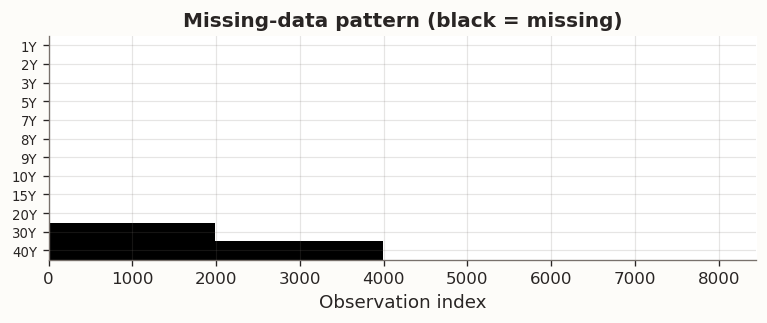

In [21]:
#| echo: false
#| warning: false
#| label: fig-missing-data-pattern
#| fig-cap: "Missing-data pattern in the full 12-tenor JGB panel"

# ── Build 12-tenor panel from earliest available date ──────────────────
# Use the first date where the core short-to-medium tenors (1Y–20Y) all
# have data. 30Y (~1999) and 40Y (~2007) are allowed to be NaN before
# their respective issuance dates.
core_tenors = ['1Y','2Y','3Y','5Y','7Y','8Y','9Y','10Y','15Y','20Y']
long_tenors = ['30Y','40Y']
all_tenors_ext = core_tenors + long_tenors
available_ext = [c for c in all_tenors_ext if c in jgb_yields_raw.columns]
core_available = [c for c in core_tenors if c in jgb_yields_raw.columns]

# Panel start: first date where all 10 core tenors have data
core_start = jgb_yields_raw[core_available].dropna(how='any').index.min()
if pd.isna(core_start):
    core_start = jgb_yields_raw.index.min()

jgb_yields_ext = jgb_yields_raw[available_ext].copy().sort_index()
jgb_yields_ext = jgb_yields_ext.loc[core_start:]

# Forward-fill sporadic gaps (limit=5) per tenor individually.
# This does NOT fill the structural missing blocks for 30Y/40Y because
# those are contiguous blocks at the start of the panel (far beyond 5 days).
jgb_yields_ext = jgb_yields_ext.interpolate(limit=5, limit_direction='forward')

# Drop rows where ALL core tenors are NaN (should be none after the filter above)
jgb_yields_ext = jgb_yields_ext.dropna(subset=core_available, how='any')

# Yield changes
jgb_changes_ext = jgb_yields_ext.diff().iloc[1:]

# Sort by maturity
tenor_labels_ext = list(jgb_changes_ext.columns)
maturities_ext = np.array([_parse_maturity(c) for c in tenor_labels_ext], dtype=float)
order_ext = np.argsort(maturities_ext)
maturities_ext = maturities_ext[order_ext]
tenor_labels_ext = [tenor_labels_ext[i] for i in order_ext]
jgb_changes_ext = jgb_changes_ext[tenor_labels_ext]

X_ext = jgb_changes_ext.to_numpy(dtype=float)
dates_ext = pd.DatetimeIndex(jgb_changes_ext.index)

# ── Missingness summary ────────────────────────────────────────────────
n_ext, p_ext = X_ext.shape
n_missing = np.isnan(X_ext).sum()
n_total = n_ext * p_ext
pct_missing = 100.0 * n_missing / n_total

missing_per_tenor = pd.Series(
    np.isnan(X_ext).sum(axis=0), index=tenor_labels_ext, name='missing_days'
)

# Per-tenor first/last valid dates
first_valid = {}
for t in tenor_labels_ext:
    s = jgb_changes_ext[t].dropna()
    first_valid[t] = s.index.min().date() if len(s) > 0 else None

print(f"Extended panel: {n_ext:,} dates × {p_ext} tenors")
print(f"Panel starts: {dates_ext[0].date()}, ends: {dates_ext[-1].date()}")
print(f"Total entries: {n_total:,}  |  Missing: {n_missing:,}  ({pct_missing:.1f}%)")
print(f"\nMissing days per tenor (structurally missing tenors only):")
for t in tenor_labels_ext:
    nm = missing_per_tenor[t]
    if nm > 0:
        print(f"  {t}: {nm:,} missing ({100*nm/n_ext:.1f}%), first valid: {first_valid[t]}")

# ── Visualise missingness pattern ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 2.8))
mask_matrix = np.isnan(X_ext).astype(float)
ax.imshow(mask_matrix.T, aspect='auto', cmap='Greys', interpolation='none',
          extent=[0, n_ext, p_ext - 0.5, -0.5])
ax.set_yticks(range(p_ext))
ax.set_yticklabels(tenor_labels_ext, fontsize=8)
ax.set_xlabel('Observation index')
ax.set_title('Missing-data pattern (black = missing)')
plt.tight_layout()
plt.show()

  PCA: τ=0.0000, ρ=0.00, recon=0.9951
  Day: τ=0.0300, ρ=1.00, recon=0.9895
  Tenor: τ=0.0000, ρ=0.00, recon=0.9951
  Day+Tenor: τ=0.1000, ρ=0.25, recon=0.9894


,tau,rho,recon_error,loading_roughness,score_roughness
model,,,,,
PCA,0.0000,0.0000,0.9951,0.0006,8542129.0857
Day,0.0300,1.0000,0.9895,0.0008,34103.8347
Tenor,0.0000,0.0000,0.9951,0.0006,8542129.0857
Day+Tenor,0.1000,0.2500,0.9894,0.0008,45232.2746


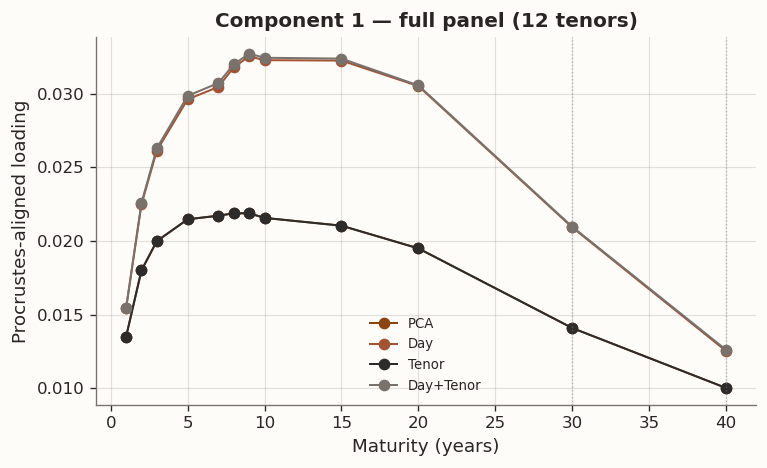

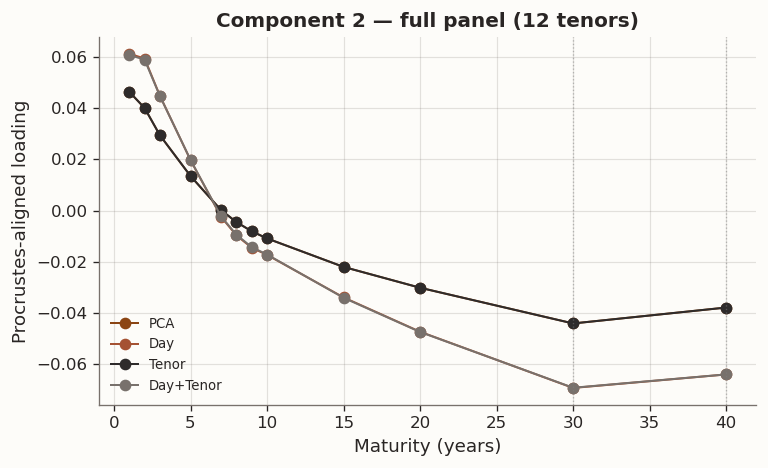

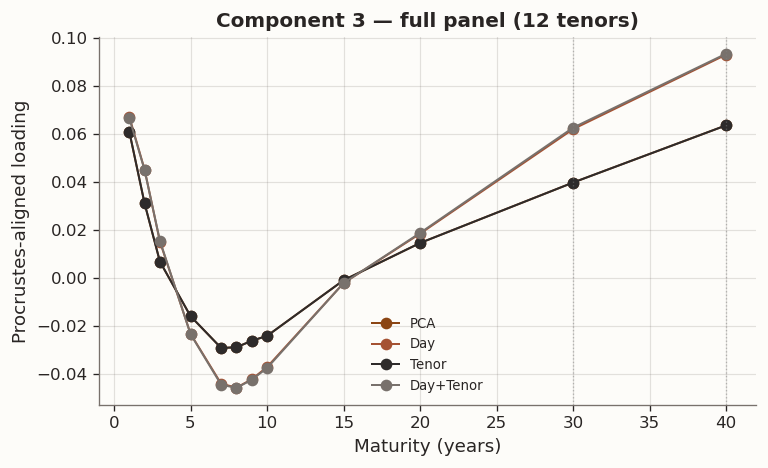

In [22]:
#| echo: false
#| warning: false
#| label: fig-missing-data-models
#| fig-cap: "Full-sample fit on the 12-tenor panel with structural missingness in 30Y and 40Y"

# ── Build graphs for the extended panel ────────────────────────────────
W_tenor_ext, L_tenor_ext, Ltilde_tenor_ext = tenor_chain_graph(maturities_ext)
W_day_ext, L_day_ext, Ltilde_day_ext = day_chain_graph(dates_ext, normalize=True)

k_ext = 3

# ── Model specifications ───────────────────────────────────────────────
ext_specs = {
    'PCA': dict(graph=None, example_graph=None, tau=0.0, rho=0.0),
    'Day': dict(
        graph=None, example_graph=Ltilde_day_ext,
        cv='nested_ts', tau_grid=tau_grid, rho_grid=np.array([1.0]),
        delta=0.01,
    ),
    'Tenor': dict(
        graph=Ltilde_tenor_ext, example_graph=None,
        cv='nested_ts', tau_grid=tau_grid, rho_grid=np.array([0.0]),
        delta=0.01,
    ),
    'Day+Tenor': dict(
        graph=Ltilde_tenor_ext, example_graph=Ltilde_day_ext,
        cv='nested_ts', tau_grid=tau_grid, rho_grid=np.array([0.25, 0.5, 0.75]),
        delta=0.01,
    ),
}

# ── Fit all models ─────────────────────────────────────────────────────
fitted_ext = {}
for name, spec in ext_specs.items():
    model = GraphRegularizedPCA(
        n_components=k_ext,
        standardize=True,
        **spec,
    )
    model.fit(X_ext, dates=dates_ext)
    fitted_ext[name] = model
    print(f"  {name}: τ={model.tau_:.4f}, ρ={model.rho_:.2f}, "
          f"recon={model.reconstruction_error(X_ext, k=k_ext):.4f}")

# ── Summary table ──────────────────────────────────────────────────────
ext_rows = []
for name, model in fitted_ext.items():
    recon = float(model.reconstruction_error(X_ext, k=k_ext))
    f_rough = float(feature_roughness(model.V_, Ltilde_tenor_ext))
    s_rough = float(example_roughness(model.U_, Ltilde_day_ext))
    ext_rows.append({
        'model': name,
        'tau': float(model.tau_),
        'rho': float(model.rho_),
        'recon_error': recon,
        'loading_roughness': f_rough,
        'score_roughness': s_rough,
    })
summary_ext_df = pd.DataFrame(ext_rows)
display(style_results_table(summary_ext_df, precision=4, index_col='model'))

# ── Procrustes alignment to PCA ────────────────────────────────────────
V_pca_ext = fitted_ext['PCA'].V_.copy()
aligned_ext = {'PCA': V_pca_ext.copy()}
for name in ['Day', 'Tenor', 'Day+Tenor']:
    V_m = fitted_ext[name].V_.copy()
    cross = V_m.T @ V_pca_ext
    U_svd, _, Wt_svd = np.linalg.svd(cross, full_matrices=False)
    R = U_svd @ Wt_svd
    aligned_ext[name] = V_m @ R

# ── Loading comparison (12 tenors) ─────────────────────────────────────
model_order_ext = ['PCA', 'Day', 'Tenor', 'Day+Tenor']
for comp in range(k_ext):
    fig, ax = plt.subplots(figsize=(6.5, 4))
    for i, name in enumerate(model_order_ext):
        ax.plot(maturities_ext, aligned_ext[name][:, comp],
                marker='o', lw=1.2, label=name, color=BLOG_PALETTE[i])
    ax.axvline(x=30, color='grey', ls=':', lw=0.8, alpha=0.5)
    ax.axvline(x=40, color='grey', ls=':', lw=0.8, alpha=0.5)
    ax.set_title(f'Component {comp + 1} — full panel (12 tenors)')
    ax.set_xlabel('Maturity (years)')
    ax.set_ylabel('Procrustes-aligned loading')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

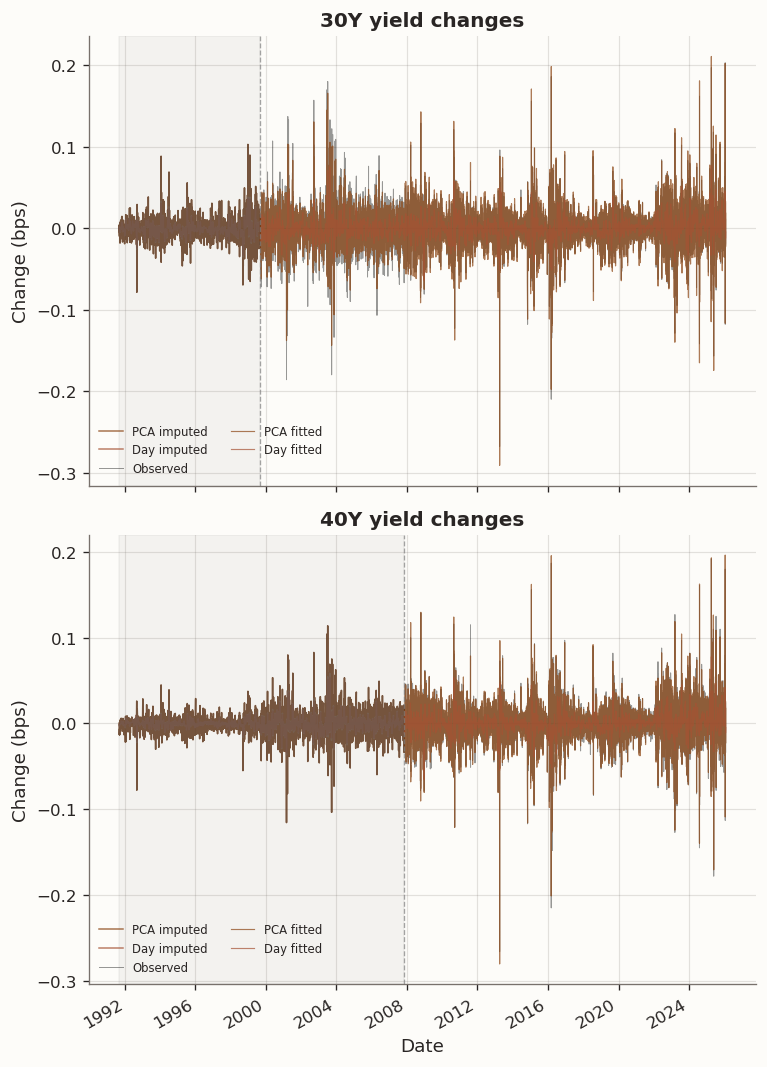

Reconstruction RMSE on observed entries (standardised scale):


tenor,30Y,40Y
model,,
Day,0.8801,0.8845
Day+Tenor,0.8655,0.8700
PCA,0.2026,0.1661
Tenor,0.2026,0.1661


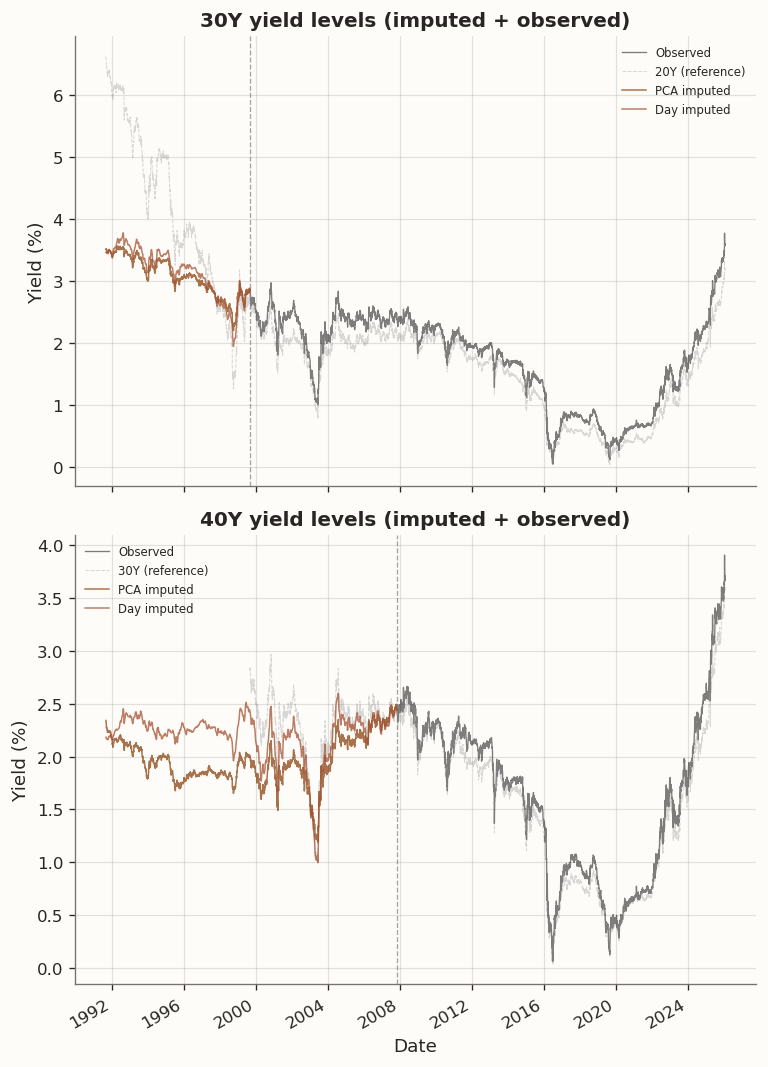

In [23]:
#| echo: false
#| warning: false
#| label: fig-imputation
#| fig-cap: "Imputed yield changes and reconstructed yield levels for structurally missing tenors"

# ── Helper: identify structurally missing period for a tenor ───────────
def _structural_missing_mask(tenor, changes_df, dates_idx):
    """Return boolean mask for dates before the tenor's first valid change."""
    s = changes_df[tenor].dropna()
    if len(s) == 0:
        return np.ones(len(dates_idx), dtype=bool)
    first_valid = s.index.min()
    return dates_idx < first_valid

missing_tenors = ['30Y', '40Y']  # tenors with structural missingness
focus_models = ['PCA', 'Day']     # main models to highlight

# ── Panel A: imputed yield changes ─────────────────────────────────────
fig, axes = plt.subplots(len(missing_tenors), 1, figsize=(6.5, 4.5 * len(missing_tenors)),
                         sharex=True)
if len(missing_tenors) == 1:
    axes = [axes]

rmse_table = []

for ax, tenor in zip(axes, missing_tenors):
    col_idx = tenor_labels_ext.index(tenor)
    observed = X_ext[:, col_idx].copy()
    struct_mask = _structural_missing_mask(tenor, jgb_changes_ext, dates_ext)
    overlap_mask = (~np.isnan(observed)) & (~struct_mask)

    # Shade the structural-missing period
    missing_dates = dates_ext[struct_mask]
    if len(missing_dates) > 0:
        ax.axvspan(missing_dates[0], missing_dates[-1],
                   color='grey', alpha=0.08)

    # Imputed values in the missing period
    if len(missing_dates) > 0:
        for i, name in enumerate(model_order_ext):
            model = fitted_ext[name]
            Z_hat = model.U_ @ model.V_.T
            imputed = Z_hat[struct_mask, col_idx] * model.scale_[col_idx] + model.mean_[col_idx]
            lbl = f'{name} imputed' if name in focus_models else '_nolegend_'
            alpha = 0.75 if name in focus_models else 0.4
            ax.plot(missing_dates, imputed, lw=0.9, alpha=alpha,
                    color=BLOG_PALETTE[i], label=lbl)

    # Observed + fitted in the overlap period
    obs_dates = dates_ext[overlap_mask]
    obs_vals = observed[overlap_mask]
    if len(obs_dates) > 0:
        ax.plot(obs_dates, obs_vals, lw=0.6, color='black', alpha=0.4, label='Observed')
        for i, name in enumerate(focus_models):
            model = fitted_ext[name]
            Z_hat = model.U_ @ model.V_.T
            fitted_vals = Z_hat[overlap_mask, col_idx] * model.scale_[col_idx] + model.mean_[col_idx]
            ax.plot(obs_dates, fitted_vals, lw=0.7, alpha=0.7,
                    color=BLOG_PALETTE[i], label=f'{name} fitted')

    # Boundary marker
    first_valid = jgb_changes_ext[tenor].dropna().index.min()
    if pd.notna(first_valid):
        ax.axvline(first_valid, color='grey', ls='--', lw=0.8, alpha=0.7)

    ax.set_title(f'{tenor} yield changes')
    ax.set_ylabel('Change (bps)')
    ax.grid(alpha=0.2)
    ax.legend(fontsize=7, ncols=2, loc='lower left')

    # RMSE on observed entries per model
    for name in model_order_ext:
        model = fitted_ext[name]
        Z_hat = model.U_ @ model.V_.T
        Z_std = (X_ext[overlap_mask, col_idx] - model.mean_[col_idx]) / model.scale_[col_idx]
        Z_hat_std = Z_hat[overlap_mask, col_idx]
        rmse = np.sqrt(np.nanmean((Z_std - Z_hat_std)**2))
        rmse_table.append({'tenor': tenor, 'model': name, 'RMSE': rmse})

axes[-1].set_xlabel('Date')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# ── RMSE table ─────────────────────────────────────────────────────────
rmse_df = pd.DataFrame(rmse_table).pivot(index='model', columns='tenor', values='RMSE')
rmse_df = rmse_df[missing_tenors]
rmse_df.index.name = 'model'
print("Reconstruction RMSE on observed entries (standardised scale):")
display(style_results_table(rmse_df.reset_index(), precision=4, index_col='model'))

# ── Panel B: reconstructed yield levels ────────────────────────────────
# For each structurally missing tenor, cumulate imputed daily changes
# backward from the first observed yield level to reconstruct pre-issuance
# yield levels.

fig, axes = plt.subplots(len(missing_tenors), 1, figsize=(6.5, 4.5 * len(missing_tenors)),
                         sharex=True)
if len(missing_tenors) == 1:
    axes = [axes]

for ax, tenor in zip(axes, missing_tenors):
    col_idx = tenor_labels_ext.index(tenor)
    struct_mask = _structural_missing_mask(tenor, jgb_changes_ext, dates_ext)

    # First observed yield level (from the yields panel, not changes)
    first_valid_yield_date = jgb_yields_ext[tenor].dropna().index.min()
    if pd.isna(first_valid_yield_date):
        ax.set_title(f'{tenor} — no observed yield levels available')
        continue

    anchor_yield = jgb_yields_ext.loc[first_valid_yield_date, tenor]

    # Plot observed yield levels
    obs_yields = jgb_yields_ext[tenor].dropna()
    ax.plot(obs_yields.index, obs_yields.values, lw=0.8, color='black',
            alpha=0.5, label='Observed')

    # Plot neighboring tenors for reference (lightly)
    neighbors = {'30Y': ['20Y'], '40Y': ['30Y']}
    for nb in neighbors.get(tenor, []):
        if nb in jgb_yields_ext.columns:
            nb_series = jgb_yields_ext[nb].dropna()
            ax.plot(nb_series.index, nb_series.values, lw=0.6, color='grey',
                    alpha=0.3, ls='--', label=f'{nb} (reference)')

    # Reconstruct imputed yield levels by cumulating changes backward
    # from the anchor date
    missing_period_dates = dates_ext[struct_mask]
    if len(missing_period_dates) > 0:
        for i, name in enumerate(focus_models):
            model = fitted_ext[name]
            Z_hat = model.U_ @ model.V_.T
            # Full series of imputed changes (missing + observed)
            all_imputed_changes = Z_hat[:, col_idx] * model.scale_[col_idx] + model.mean_[col_idx]

            # Find the change-index position of the anchor yield date
            # The anchor yield date should align with a change date (or close to it)
            anchor_change_idx = np.searchsorted(dates_ext, first_valid_yield_date)
            if anchor_change_idx >= len(dates_ext):
                anchor_change_idx = len(dates_ext) - 1

            # Build yield levels: backward from anchor
            imputed_levels = np.full(len(dates_ext), np.nan)
            imputed_levels[anchor_change_idx] = anchor_yield

            # Backward: y_{t} = y_{t+1} - change_{t+1}
            for t in range(anchor_change_idx - 1, -1, -1):
                imputed_levels[t] = imputed_levels[t + 1] - all_imputed_changes[t + 1]

            # Only plot the missing period
            lbl = f'{name} imputed'
            ax.plot(missing_period_dates, imputed_levels[struct_mask],
                    lw=0.9, alpha=0.75, color=BLOG_PALETTE[i], label=lbl)

    # Boundary marker
    if pd.notna(first_valid_yield_date):
        ax.axvline(first_valid_yield_date, color='grey', ls='--', lw=0.8, alpha=0.7)

    ax.set_title(f'{tenor} yield levels (imputed + observed)')
    ax.set_ylabel('Yield (%)')
    ax.grid(alpha=0.2)
    ax.legend(fontsize=7, loc='best')

axes[-1].set_xlabel('Date')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The full panel starts from the earliest date where all 10 core tenors (1Y–20Y) are available, extending the sample backward by several years relative to the main analysis. The 30Y and 40Y columns introduce two contiguous missing-data blocks: 30Y is structurally absent before ~1999, and 40Y before ~2007. Together these produce a substantially higher missing-data fraction than the 40Y-only setup in the earlier version of this appendix.

The results table and loading plots above show the same qualitative pattern as the main-body full-sample study: cross-validation selects $\tau = 0$ for the Tenor model (no maturity-axis benefit), while the Day and Day+Tenor models accept a modest reconstruction penalty in exchange for sharply reduced score roughness.

The imputed yield changes for both 30Y and 40Y display plausible time-varying volatility through the missing period. The 30Y imputation is notably cleaner than the 40Y: the 30Y's nearest observed neighbor is the 20Y at a 10-year gap, while the 40Y must extrapolate from 30Y loadings that are themselves estimated from a partially observed column during the early period. The RMSE table on the observed overlap period confirms the expected pattern: PCA and Tenor achieve the lowest per-tenor RMSE, while Day and Day+Tenor trade reconstruction fidelity for temporal smoothness.

The yield-level reconstruction cumulates imputed daily changes backward from the first observed yield level. For 30Y, the imputed levels track the 20Y reference curve during the pre-1999 period with a plausible spread. For 40Y, the imputed levels sit *below* the 30Y throughout the pre-2007 period---a pattern that warrants discussion. In principle an inverted 30Y–40Y spread is not impossible: convexity return at the ultra-long end introduces a negative yield adjustment $-\tfrac{1}{2}\,\text{duration}^2\,\sigma^2$ that grows with maturity, and in the post-2007 JGB market the 30Y–40Y spread has indeed been negative at times, driven by Japanese life insurers and pension funds bidding aggressively for 40Y duration to hedge ultra-long liabilities. However, this inversion is predominantly a post-2007 phenomenon reflecting specific supply-demand dynamics that may not have existed in the 1990s high-rate environment. The model produces the inversion because the 40Y loading vector $v_{40\text{Y}}$ is estimated entirely from the post-2007 observed window, where those dynamics are present, and the rank-3 linear structure $\hat{x}_{t,j} = u_t^\top v_j$ applies the same loading to pre-2007 score trajectories without any mechanism to enforce monotonicity across maturities or to accommodate regime-dependent loading relationships. This is a limitation of linear factor imputation: the model extrapolates a single set of loadings across the entire sample, which can produce implausible cross-sectional orderings when the loading structure is regime-dependent. The tenor-chain penalty could in principle mitigate this by shrinking the 40Y loading toward the 30Y loading, but cross-validation selects $\tau = 0$, leaving this channel inactive.

The reconstructed levels are most useful as inputs for downstream applications that require a complete panel (e.g., covariance estimation across the full yield curve history), but we should be aware that the imputed 40Y levels in the pre-2007 period reflect post-2007 loading geometry and may understate the true 30Y–40Y spread in the earlier regime.